<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">

<h1 style="margin-bottom:0;"><b>Data Preprocessing and Visualization - Final Project</b></h1>
<br>

<h1 style="margin-top:5px; color:#009E91;"><b>"City Hospital" </b></h1>

<h2 style="color:#009E91; margin-top:-5px;"><b>Data Preprocessing & Exploratory Analysis</b></h2>



<h3><b>DP Team - Group 7</b></h3>

<ul style="margin-top:-10px;">
<li><b>Carlota Marto</b> — 20241729</li>
<li><b>Henrique Santos</b> — 20241752</li>
<li><b>Laura Lisboa</b> — 20241783</li>
<li><b>Tiago Carvalho</b> — 20241728</li>
</ul>

<br>

<h4>LCD  —  Teachers: Cong Liu  — 2025/26 </h4>

</div>



<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

    
**Table of Contents**

**1.Introduction**

1.1. Project Context and Goal

**Part A – Data Understanding & Cleaning.**

2.1. Imports\
2.2. Preprocessing Data
<ul style="margin-top:-10px;">
    
  2.2.1. Duplicate Records \
  2.2.2  Handling Inconsistencies \
  2.2.3. Missing Values - Categorical(3) / Numerical (3)\
  2.2.4. Outliers  \
  2.2.5. Adjusting Data Types 
</ul>

**Part B – Feature Engineering & ABT Construction.**

3.1. Static attributes (demographics)\
3.2. Aggregated behavior from all visits\
3.3. Recency & activity\
3.4.  ABT exportation


**Part C – Exploratory Visualization & Insights**

4.1.  Patient demographics: Age, Gender, and income
distributions\
4.2. Department & Service Usage\
4.3. Satisfaction: Department and Patient Segment \
4.4. Other plots \

**5.   Suggestions for next analytics team** \
5.1. Project Conclusion\
5.2. Suggestions for the Next Analytics Team


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">
<h3><b>1. Introduction </b></h3>


 <div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> 1.1. Project Context and Goal

**Project Context**\
The following project was **design by the Data Preprocessing Team, DPT**, that is part of the City Hospital´s Data Science Group. \
Currently, the hospital lacks comprehensive information regarding its patient behaviors and activities.

So, the DPT is in charge of the preparation of City Hospital´s data for advanced analytical methods and of providing initial insights into the hospital operations and patient care patterns. 

**Project Goal** \
City Hospital requires an **exploratory analysis** to address fundamental operational questions and an **analytic-based table (ABT)** for descriptive analysis and patient segmentation.

The primary objective of the DPT is not to build predictive models, but to utilize data from the hospital’s information systems to create an ABT, which will then be handed over to the next team for further analysis and implementation. So, we divided our work in: 
<ul style="margin-top:-10px;">
  <li> PART A - Perform Data Preprocessing: Conduct data understanding and preprocessing to ensure patient-level data is ready for future prediction and clustering tasks; </li> 
  <li> PART B - Construct the ABT: An ABT at the patient level, ensuring there is one row per patient; </li>
  <li> PART C - Generate Insights: Provide exploratory visualizations and initial business insights for both City Hospital management and the subsequent analytics team. </li>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">
<h3><b>Part A – Data Understanding & Cleaning </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.1 Imports
   

Import of Necessary Libraries:

In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')


Import of the given Dataset:

In [159]:
dataset = pd.read_excel('Project Data.xlsx', index_col = 0)
print("The dataset has {} rows and {} columns".format(dataset.shape[0], dataset.shape[1]))
dataset.head()

The dataset has 10008 rows and 15 columns


,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-02-22,Endocrinology,110,2,38839.0,293.014042,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-01-21,Emergency,76,4,52219.0,287.208982,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-06-13,Neurology,17,5,41491.0,241.254507,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-24,Emergency,15,3,34944.0,221.177483,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-19,Neurology,99,1,39248.0,219.743794,0.0


In [160]:
dataset = dataset.rename(columns={'Consultation Duration': 'Consultation Duration (min)', 
                                  'Satisfaction Level': 'Satisfaction Level (1-5)',
                                   'Consultation Price': 'Consultation Price(£)',
                                   'Insurance Coverage': 'Insurance Coverage(£)'}) #adding some info to the columns names to better understanding

In [161]:
dataset.head(1)

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-02-22,Endocrinology,110,2,38839.0,293.014042,0.0


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2. Preprocessing Data
   

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.1. How to Handle Duplicate Records

We chose to handle the **duplicate records firstly** so that those records do not interfere with the imputation of the missing values.

In [162]:
duplicate_records = dataset[dataset.duplicated(keep = False)]
duplicate_records.shape
#these two lines shows us the duplicate records in the dataset

(16, 15)

We can see that the dataframe created (that shows the duplicate records) above has 16 rows, which means there are 8 duplicate records in the whole dataset, therefore, we need to remove those 8 lines

In [163]:
dataset.drop_duplicates(inplace = True)
print("The dataset now has {} rows and {} columns".format(dataset.shape[0], dataset.shape[1]), 'which means the duplicate records have all been removed sucessfully.')

The dataset now has 10000 rows and 15 columns which means the duplicate records have all been removed sucessfully.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.2. Handling Inconsistent Records

Datasets frequently contain **logical inconsistencies** (for instance, a 5-year-old classified as a 'Doctor'). These records are technically present in the dataset but do not make any sense in a real-world context. This step is dedicated to identifying and correcting these errors, which are different from missing data.

We chose to handle these inconsistencies before the imputation of the missing values as we often use conditional imputation and, if they are left uncorrected, it distorts the groups statistics, such as the median, mean or mode. So in this way we ensure that the statistical basis is clean, stable and accurate.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> Our Solution: </b>

We cannot just check the records one by one until we find some inconsistency. Instead, we will define **simple, logical rules** (for example, one has to be at least 18 years old to have a job) that the computer will use to instantly identify **every incorrect record**. This approach is essential because it allows us to find all problem rows with a single, fast query, even in a dataset with billions of records. A **new column called** `Is_Valid` is then created using Boolean values to mark as "False" any records that do not obbey these rules.

This is a **simple** and **fast** way to check every record of the dataset. After every incorrect record is identified, we will then proceed to **analyse every case** marked as "not valid" and find the best way to deal with it.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.2. Handling Inconsistent Records <b>- First Rule: Every pacient under 18 years old has to be a student and can´t have income.

In [164]:
dataset['Is_Valid'] = ~((dataset['Age'] < 18.0) & (dataset['Profession'] != 'Student'))
dataset.index[dataset['Is_Valid']== False].value_counts()

Patient ID
1433    35
1181    25
1398    20
1479    14
1496    13
1488     2
Name: count, dtype: int64

The cell above shows us how many rows of each patient presented that don´t follow this rule. \
Now, we are going to treat those 6 patients one by one to see how to deal with every case specifically, because the mistake can be in the age and not in the profession, for example.

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1433**

In [165]:
dataset[dataset.index == 1433].head(2) #this line shows us the first 5 records of patient 1433

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1433,9.0,Other,Dublin,Teacher,Provider A,NaN,Elementary school,Single,2024-04-05,Emergency,82,2,0.0,339.210405,271.368324,False
1433,9.0,Other,Dublin,Teacher,Provider A,NaN,Elementary school,Single,2024-05-24,Emergency,110,3,0.0,335.900910,268.720728,False


We can observe in the table above that the Pacient 1433 has 9 years old and works as teacher. As we can see in the other observations, the education level of this pacient is 'Elementary School' and he also does not have any annual income, therefore he cannot work as teacher and it is in fact a mistake. We are going to substitute his profession with 'Student' in the next line.

In [166]:
dataset.loc[dataset.index == 1433, 'Profession'] = 'Student'
dataset[dataset.index == 1433].head(2) #this line is just to verify the changes, the next time we will not show the changes

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1433,9.0,Other,Dublin,Student,Provider A,NaN,Elementary school,Single,2024-04-05,Emergency,82,2,0.0,339.210405,271.368324,False
1433,9.0,Other,Dublin,Student,Provider A,NaN,Elementary school,Single,2024-05-24,Emergency,110,3,0.0,335.900910,268.720728,False


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1181**

In [167]:
dataset[dataset.index == 1181].head(2) #this line shows us the first 5 records of patient 1181

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1181,1.0,Female,London,Lawyer,Provider C,Hypertension,Pre-school,Single,2024-05-24,Emergency,49,4,0.0,347.636118,243.345283,False
1181,1.0,Female,London,Lawyer,Provider C,Hypertension,Pre-school,Single,2024-01-04,Emergency,84,3,0.0,302.001055,211.400739,False


In [168]:
dataset.loc[dataset.index == 1181, 'Profession'] = 'Student' 

In this case, it is basically the same as the last one. Therefore, by the same logic we are gonna replace the 'Lawyer' with 'Student'.

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1398**

This patient is classified as a Doctor and has 5 years old.She is in kindergaten and has no annual income, we consider it a mistake. We will repeat the process.

In [169]:
dataset[dataset.index == 1398].head(2)

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1398,5.0,Female,Glasgow,Doctor,Provider D,Cancer,Kindergarten,Single,2024-03-30,Emergency,91,2,0.0,388.800450,388.800450,False
1398,5.0,Female,Glasgow,Doctor,Provider D,Cancer,Kindergarten,Single,2024-01-18,Emergency,51,3,0.0,320.343845,320.343845,False


In [170]:
dataset.loc[dataset.index == 1398, 'Profession'] = 'Student'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1479**

This patient is retired with 11 years old. She studies in Middle school/junior high and has no annual income therefore, we consider it a mistake. We will repeat the process and replace the Profession with 'Student'.

In [171]:
dataset[dataset.index == 1479].head(2)

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1479,11.0,Female,Glasgow,Retired,Provider A,Heart Disease,Middle school/junior high,Single,2024-02-15,Emergency,81,2,0.0,375.542442,300.433954,False
1479,11.0,Female,Glasgow,Retired,Provider A,Heart Disease,Middle school/junior high,Single,2024-03-20,Neurology,46,1,0.0,278.905030,223.124024,False


In [172]:
dataset.loc[dataset.index == 1479, 'Profession'] = 'Student'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1496**

This patient is retired with 4 years old. He studies in Pre school and has no annual income therefore, we consider it a mistake. We will repeat the process and replace the Profession with 'Student'.

In [173]:
dataset[dataset.index == 1496].head(2)

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1496,4.0,Other,Belfast,Retired,Provider B,Hypertension,Pre-school,Single,2024-04-22,Emergency,20,1,0.0,336.082966,302.474669,False
1496,4.0,Other,Belfast,Retired,Provider B,Hypertension,Pre-school,Single,2024-06-18,Emergency,98,4,0.0,263.757667,237.381900,False


In [174]:
dataset.loc[dataset.index == 1496, 'Profession'] = 'Student'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1488**

This patient is retired with 11 years old. She studies in Middle school/junior high and has no annual income therefore, we consider it a mistake. We will repeat the process and replace the Profession with 'Student'.

In [175]:
dataset[dataset.index == 1488].head(2)

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1488,11.0,Female,London,Retired,Provider A,NaN,Middle school/junior high,Single,2024-04-15,Emergency,18,1,0.0,353.526304,282.821043,False
1488,11.0,Female,London,Retired,Provider A,NaN,Middle school/junior high,Single,2024-05-08,Neurology,102,5,0.0,237.527346,190.021876,False


In [176]:
dataset.loc[dataset.index == 1488, 'Profession'] = 'Student'

**Just to check if we still have inconsistencies regarding this topic:**

In [177]:
dataset['Is_Valid'] = ~((dataset['Age'] < 18.0) & (dataset['Profession'] != 'Student'))
dataset.index[dataset['Is_Valid']== False].value_counts()

Series([], Name: count, dtype: int64)

In [178]:
dataset['Is_Valid'] = True #just to reset
dataset['Is_Valid'] = ~((dataset['Age'] <= 18) & (dataset['Approximate Annual Income'] > 0))
dataset[dataset['Is_Valid'] == False].shape 

(0, 16)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
This means there aren't people with age <=18 years old with income.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.2. Handling Inconsistent Records <b>- Second Rule - There cannot exist people with more than 120 years old.

Our second rule will be that the records of people with ages above 120 years old will be considered invalid. Then, we will check these incidents one by one to check what type of error they are:

In [179]:
dataset['Is_Valid'] = ~((dataset['Age'] > 120.0)) # we replace the before column 'Is Valid' rule to the new rule
dataset.index[dataset['Is_Valid']== False].value_counts() #we can see that there are 4 patients with ages above 120

Patient ID
1198    21
1000    20
1319    19
1180    16
Name: count, dtype: int64

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1198**

Here we will see if every age value of the patient 1198 is above 120.

In [180]:
dataset['Age'][dataset.index == 1198].value_counts() 

Age
138.0    21
38.0      1
Name: count, dtype: int64

In [181]:
dataset[dataset.index == 1198]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-05,Emergency,96,3,31943.0,392.481959,313.985567,True
1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-20,Emergency,102,1,41550.0,334.332430,267.465944,False
1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-26,Emergency,81,4,36876.0,329.961479,263.969183,False
1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-26,Endocrinology,22,1,42020.0,253.714079,202.971263,False
1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-05-04,Cardiology,39,2,52556.0,237.424702,189.939761,False
1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-01-29,Neurology,118,1,30307.0,231.853636,185.482909,False
1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-02-29,Cardiology,105,2,42035.0,229.341788,183.473430,False
1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-05-31,Emergency,114,4,56192.0,228.609639,182.887711,False
1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-20,Neurology,43,4,59492.0,212.723299,170.178639,False


We can see that there is one record where the patient is classified as an 38 year old. Therefore, we decided to assume that the real age of the patient is 38 and all the other records were a mistake (an 1 added before 38). 

In [182]:
dataset.loc[dataset.index == 1198, 'Age'] = 38 #this line replaces the age of 138 with 38

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1000**

In [183]:
dataset['Age'][dataset.index == 1000].value_counts()

Age
158.0    20
Name: count, dtype: int64

All of the records of the age of patient 1000 are the same, with the age of 158. As it is a different situation from the last one, we cannot just assume what age she has, so, by now, we are going to treat it as a missing value and will deal with it later on the notebook.

In [184]:
dataset.loc[(dataset.index ==1000) & (dataset['Age'] == 158.0), 'Age'] = np.nan

In [185]:
dataset[dataset.index == 1000].head(2)

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,50,4,54388.0,381.222958,381.222958,False
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-05,Cardiology,88,1,35475.0,278.363705,278.363705,False


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1319**

In [186]:
dataset['Age'][dataset.index == 1319].value_counts()

Age
142.0    19
Name: count, dtype: int64

Doing the same as the pacient before:

In [187]:
dataset.loc[(dataset.index ==1319) & (dataset['Age'] == 142.0), 'Age'] = np.nan

In [188]:
dataset[dataset.index == 1319].head(2)

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1319,NaN,Male,Liverpool,Engineer,Provider A,NaN,Master,Widowed,2024-03-23,Emergency,80,1,55545.0,352.502773,282.002218,False
1319,NaN,Male,Liverpool,Engineer,Provider A,NaN,Master,Widowed,2024-05-09,Neurology,42,2,38843.0,271.590698,217.272558,False


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1180**

In [189]:
dataset['Age'][dataset.index == 1180].value_counts()

Age
195.0    16
Name: count, dtype: int64

Doing the same as the pacient before:

In [190]:
dataset.loc[(dataset.index ==1180) & (dataset['Age'] == 195.0), 'Age'] = np.nan

In [191]:
dataset[dataset.index == 1180].head(2)

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1180,NaN,Other,Glasgow,Retired,Provider B,Diabetes,Master,Divorced,2024-06-15,Emergency,18,4,57259.0,322.719054,290.447149,False
1180,NaN,Other,Glasgow,Retired,Provider B,Diabetes,Master,Divorced,2024-03-27,Endocrinology,20,1,30826.0,238.927804,215.035023,False


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.3. Handling Inconsistent Records <b>- Third Rule - Satisfaction Level is between 1-5.

While analysing our dataset, we found that it exits some records with the number "6" on the `Satisfaction Level`column. As it says on the guidelines, this variable is the patient evaluation of the satisfaction level with the consultation between **1 to 5**, which means that all the values not on that interval are **inconsistencies** and **must be treated**.

In [192]:
dataset['Satisfaction Level (1-5)'].value_counts()
#this line shows us all the existing values and how many times they appear, we can see there are 719 records with a value of 6.

Satisfaction Level (1-5)
2    1890
4    1886
1    1865
3    1838
5    1802
6     719
Name: count, dtype: int64

There are 719 records where the satisfaction level is 6. Therefore, we will consider it a mistake and replace all the occurences as a 5, the line of code below does that replacing.

In [193]:
dataset.loc[dataset['Satisfaction Level (1-5)'] == 6, 'Satisfaction Level (1-5)'] = 5

In [194]:
dataset['Satisfaction Level (1-5)'].value_counts() #just to verify it worked and we do not have the value '6' anymore

Satisfaction Level (1-5)
5    2521
2    1890
4    1886
1    1865
3    1838
Name: count, dtype: int64

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.3. Handling Inconsistent Records <b>- Fourth Rule - Insurance Coverage has to always be less or equal than the Consultation Price.

We are going to use the column called `Is_Valid` again. The value of that column will be "False" if the Insurance Coverage exceeds the Consultation Price. By using the line of code below, we discover there are 6 cases where that happens.

In [195]:
dataset['Is_Valid'] = ~((dataset['Insurance Coverage(£)'] > dataset['Consultation Price(£)'])) #condition
dataset[dataset['Is_Valid']== False] 

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1211,68.0,Male,Edinburgh,Retired,Provider A,Diabetes,Undergraduate,Divorced,2024-03-12,ENT,17,5,51194.0,50.287175,140.229740,False
1344,18.0,Other,Birmingham,Student,Provider B,NaN,High school,Single,2024-03-20,Emergency,105,4,0.0,357.653151,421.887836,False
1021,14.0,Male,London,Student,Provider B,NaN,High school,Single,2024-03-13,General Practice,44,5,0.0,50.047001,55.042301,False
1443,16.0,Male,Belfast,Student,Provider D,NaN,High school,Single,2024-01-22,General Practice,44,1,0.0,83.232090,93.232090,False
1230,40.0,Male,Edinburgh,Artist,Provider D,NaN,PhD,Divorced,2024-02-03,Emergency,105,4,83886.0,396.312644,400.312644,False
1028,41.0,Male,Birmingham,Engineer,Provider D,Diabetes,Undergraduate,Married,2024-04-12,Gastroenterology,118,5,48428.0,199.216286,299.216286,False


In this cases, we decided to set the **`Insurance Coverage` = `Consultation Price`**.

In [196]:
dataset.loc[(dataset['Is_Valid'] == False), "Insurance Coverage(£)"] = dataset.loc[(dataset['Is_Valid'] == False), "Consultation Price(£)"] #this line changes the value of insurance coverage
print(dataset.loc[(dataset['Is_Valid'] == False), ["Insurance Coverage(£)", "Consultation Price(£)", "Is_Valid"]].head()) #this shows the change


            Insurance Coverage(£)  Consultation Price(£)  Is_Valid
Patient ID                                                        
1211                    50.287175              50.287175     False
1344                   357.653151             357.653151     False
1021                    50.047001              50.047001     False
1443                    83.232090              83.232090     False
1230                   396.312644             396.312644     False


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.3. Handling Inconsistent Records <b>- Fifth Rule - Differents records of the same patient need to have the same attributes for the some columns.

We will not analyse the following columns: `Visit Date`, `Department`, `Consultation Duration (min)`, `Satisfaction Level (1-5)`, `Consultation Price(£)`, `Insurance Coverage(£)`, `Is_Valid`. The following code will give us a table with records of patients and the numbers of unique values, which means, that the columns that have a value of "2" need to be analysed.

In [197]:
notused_columns = ['Visit Date', 'Department', 'Consultation Duration (min)', 'Satisfaction Level (1-5)', 'Consultation Price(£)','Approximate Annual Income', 'Insurance Coverage(£)', 'Is_Valid']
fifthrule_new_dataset = dataset.drop(columns = notused_columns)

consistency_check = fifthrule_new_dataset.groupby('Patient ID')[fifthrule_new_dataset.columns].nunique()

inconsistent_patients = consistency_check[consistency_check.gt(1).any(axis=1)]
inconsistent_patients

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status
Patient ID,,,,,,,,
1050,1,2,1,1,1,1,1,1
1140,1,1,1,1,1,1,1,2
1307,1,2,1,1,1,1,1,1
1322,1,1,1,1,1,1,1,2
1332,1,1,1,1,1,1,1,2
1349,1,2,1,1,0,1,1,1
1382,1,1,1,1,1,1,1,2
1447,1,2,1,1,1,1,1,1
1490,1,2,1,1,1,0,1,1


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1050**

In [198]:
dataset['Gender'][dataset.index == 1050].value_counts()

Gender
Female    14
Male       3
Name: count, dtype: int64

We have 14 records of "Female" and just 3 of "Male". We decided that the "Male" ones are mistakes so we will replace all with "Female".

In [199]:
dataset.loc[dataset.index == 1050, 'Gender'] = 'Female'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1140**

In [200]:
dataset['Marital Status'][dataset.index == 1140].value_counts()

Marital Status
Single     18
Widowed     1
Name: count, dtype: int64

In [201]:
dataset.loc[dataset.index == 1140, 'Marital Status'] = 'Single'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1307**

In [202]:
dataset['Gender'][dataset.index == 1307].value_counts()

Gender
Male      23
Female     1
Name: count, dtype: int64

In [203]:
dataset.loc[dataset.index == 1307, 'Gender'] = 'Male'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1322**

In [204]:
dataset['Marital Status'][dataset.index == 1322].value_counts()

Marital Status
Single     17
Married     2
Name: count, dtype: int64

In [205]:
dataset.loc[dataset.index == 1322, 'Marital Status'] = 'Single'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1332**

In [206]:
dataset['Marital Status'][dataset.index == 1332].value_counts()

Marital Status
Single     23
Married     1
Name: count, dtype: int64

In [207]:
dataset.loc[dataset.index == 1332, 'Marital Status'] = 'Single'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1349**

In [208]:
dataset['Gender'][dataset.index == 1349].value_counts()

Gender
Male      17
Female     1
Name: count, dtype: int64

In [209]:
dataset.loc[dataset.index == 1349, 'Gender'] = 'Male'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1382**

In [210]:
dataset['Marital Status'][dataset.index == 1382].value_counts()

Marital Status
Single     21
Widowed     1
Name: count, dtype: int64

In [211]:
dataset.loc[dataset.index == 1382, 'Marital Status'] = 'Single'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1447**

In [212]:
dataset['Gender'][dataset.index == 1447].value_counts()

Gender
Female    18
Male       2
Name: count, dtype: int64

In [213]:
dataset.loc[dataset.index == 1447, 'Gender'] = 'Female'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">

**Patient 1490**

In [214]:
dataset['Gender'][dataset.index == 1490].value_counts()

Gender
Female    24
Male       3
Name: count, dtype: int64

In [215]:
dataset.loc[dataset.index == 1490, 'Gender'] = 'Female'

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.3. Handling Inconsistent Records <b>- Sixth Rule - Retired people cannot have an annual income AND check the cases where people above 65 years old are not Retired.

Our sixth rule is to make sure that every retired people have an annual income of 0. So, after seeing how many records we have, we will replace those values by 0.

In [216]:
dataset['Is_Valid'] = True #just to reset
dataset['Is_Valid'] = ~((dataset['Profession'] == 'Retired') & (dataset['Approximate Annual Income'] > 0))
dataset[dataset['Is_Valid'] == False].shape # there are 3518 wrong records

(3518, 16)

In [217]:
dataset.loc[dataset['Is_Valid'] == False, 'Approximate Annual Income'] = 0 #changes all the values to zero


For this subsection, we will consider that the age of retirement is **65**. We will check the cases of the ones that are "supposed" to be retired but aren't and see if we find any inconsistency. If we do, we will treat, if we find it valid, we will leave it as it is.

In [218]:
dataset.loc[(dataset['Age'] > 65) & (dataset['Profession'] != 'Retired')]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1207,118.0,Other,Liverpool,Student,Provider D,Hypertension,High school,Single,2024-03-22,Emergency,34,3,0.0,360.273256,360.273256,True
1207,118.0,Other,Liverpool,Student,Provider D,Hypertension,High school,Single,2024-05-03,Neurology,81,3,0.0,299.908490,299.908490,True
1207,118.0,Other,Liverpool,Student,Provider D,Hypertension,High school,Single,2024-05-21,Endocrinology,21,1,0.0,289.083377,289.083377,True
1207,118.0,Other,Liverpool,Student,Provider D,Hypertension,High school,Single,2024-03-16,Cardiology,51,5,0.0,259.771744,259.771744,True
1207,118.0,Other,Liverpool,Student,Provider D,Hypertension,High school,Single,2024-03-08,Orthopedics,18,3,0.0,208.816037,208.816037,True
1207,118.0,Other,Liverpool,Student,Provider D,Hypertension,High school,Single,2024-06-16,Neurology,62,5,0.0,195.951884,195.951884,True
1207,118.0,Other,Liverpool,Student,Provider D,Hypertension,High school,Single,2024-05-01,Allergology,85,4,0.0,181.506186,181.506186,True
1207,118.0,Other,Liverpool,Student,Provider D,Hypertension,High school,Single,2024-06-09,Cardiology,101,1,0.0,176.206992,176.206992,True
1207,118.0,Other,Liverpool,Student,Provider D,Hypertension,High school,Single,2024-02-02,Dermatology,64,2,0.0,154.625814,154.625814,True


Here we can see that the **Patient 1207** is 118 and is classified as a "Student". We know that there is extremely unlikely, therefore, by analysing is annual income, which is zero(the normal income for retired people) and as he is 118, we will change the "Profession" of this patient to "Retired" in the line of code below.

In [219]:
dataset.loc[dataset.index == 1207, 'Profession'] = 'Retired'

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.3. Handling Inconsistent Records <b>- Seventh Rule - The ones with 0-2 years old cannot have a Profession different than "Infant" and a Education Level different than "Infant".

Every pacient with less or equal than 2 years old needs to be classified as "Infant".

Profession:

In [220]:
dataset['Age'] = pd.to_numeric(dataset['Age'], errors='coerce')

wrong = (dataset['Age'] <= 2) & (dataset['Profession'] != 'Infant')

patients_to_fix = dataset.loc[wrong].index.unique()

dataset.loc[patients_to_fix, 'Profession'] = 'Infant'

Education Level:

In [221]:
dataset['Age'] = pd.to_numeric(dataset['Age'], errors='coerce')

wrong = (dataset['Age'] <= 2) & (dataset['Education Level'] != 'Infant')

patients_to_fix = dataset.loc[wrong].index.unique()

dataset.loc[patients_to_fix, 'Education Level'] = 'Infant'

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.3. Handling Inconsistent Records <b>- Eighth Rule - Every variable that corresponds to a time, price or even age cannot be negative.

In [222]:
columns_not_negative = ['Age',
                        'Approximate Annual Income',
                        'Consultation Duration (min)',
                        'Consultation Price(£)',
                        'Insurance Coverage(£)']
dataset[((dataset[columns_not_negative]) < 0).any(axis=1)]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,


We thought that it would be better to really make sure there aren't any negative values. If that was the case in any of these columns, they would probably be wrong and we would need to solve it. But, in this case, it does not happen, therefore, we wont do anything about it.

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. How to Handle Missing Values 

In [223]:
dataset.info() #this gives us a summary of the dataset, that includes the datatypes of the columns, which is useful for later analysis

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1482 to 1012
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Age                          9889 non-null   float64       
 1   Gender                       10000 non-null  object        
 2   City of Residence            10000 non-null  object        
 3   Profession                   10000 non-null  object        
 4   Insurance Provider           8093 non-null   object        
 5   Family History               8010 non-null   object        
 6   Education Level              9971 non-null   object        
 7   Marital Status               10000 non-null  object        
 8   Visit Date                   10000 non-null  datetime64[ns]
 9   Department                   10000 non-null  object        
 10  Consultation Duration (min)  10000 non-null  int64         
 11  Satisfaction Level (1-5)     10000 non-null 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
Firstly, we need to understand how many missing values are in our dataset. With this function, we are able to see how many are in each column.

In [224]:
dataset.isna().sum()

Age                             111
Gender                            0
City of Residence                 0
Profession                        0
Insurance Provider             1907
Family History                 1990
Education Level                  29
Marital Status                    0
Visit Date                        0
Department                        0
Consultation Duration (min)       0
Satisfaction Level (1-5)          0
Approximate Annual Income       154
Consultation Price(£)             0
Insurance Coverage(£)            49
Is_Valid                          0
dtype: int64

We can conclude that exist **6** variables with missing values - **3 Categorical** (`Insurance Provider`, `Family History`, `Education Level`) and **3 Numerical** (`Age`, `Approximate Annual Income`, `Insurance Coverage`). We can affirm this information because we saw above the different datatypes of these variables.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. How to Handle Missing Values - Categorical Variables

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
1. **Insurance Provider**:

The logic will be:
<ul style="margin-top:-10px;">
<li>If Insurance Provider = NaN and Insurance Coverage(£) = 0 for all rows of same pacient -  we will replace the Insurance Provider with None.</li>
<li>If the Insurance Provider = NaN and Insurance Coverage(£) different than 0 and NaN -  we will replace the Insurance Provider associated with that consult with the Insurance Provider of the other consults of the same pacient. </li>
</ul>


Pacients with NaN in Insurance Provider and in Insurance Coverage in all rows: - If this case exists, the thing to do is nothing because is a lack of info not an error:

In [225]:
mask_all_nan = (dataset['Insurance Provider'].isna() & dataset['Insurance Coverage(£)'].isna())
patients_all_nan = mask_all_nan.groupby(dataset.index).all()
patients_all_nan_ids = patients_all_nan[patients_all_nan].index.tolist()
patients_all_nan_ids


[]

In [226]:
dataset[dataset['Insurance Provider'].isna()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-02-22,Endocrinology,110,2,0.0,293.014042,0.000000,False
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-01-21,Emergency,76,4,0.0,287.208982,0.000000,False
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-06-13,Neurology,17,5,0.0,241.254507,0.000000,False
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-24,Emergency,15,3,0.0,221.177483,0.000000,False
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-19,Neurology,99,1,0.0,219.743794,0.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-06-28,General Practice,74,2,0.0,75.489076,52.842353,False
1012,7.0,Other,Dublin,Student,NaN,Hypertension,Elementary school,Single,2024-05-13,General Practice,79,5,0.0,66.634595,0.000000,True
1012,7.0,Other,Dublin,Student,NaN,Hypertension,Elementary school,Single,2024-01-19,General Practice,96,5,0.0,55.060415,0.000000,True


**Verifying if exists pacients with different Insurances Providers to know how to replace:**


In [227]:
provider_counts = dataset['Insurance Provider'].groupby(level=0).nunique()
patients_with_diff_providers = provider_counts[provider_counts > 1]

n = len(patients_with_diff_providers)
print(f"There are {n} patients with different Insurance Providers.")

if n > 0:
    print("\nIDs of the patients with multiple Providers:")
    display(dataset.loc[patients_with_diff_providers.index].sort_index())
else:
    print("There are no patients with multiple Insurance Providers.")


There are 0 patients with different Insurance Providers.
There are no patients with multiple Insurance Providers.


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**For pacients without NaN in Insurance Coverage:** 

In [228]:
dataset['Is_Valid'] = ~((dataset['Insurance Provider'].isna()) & (~dataset['Insurance Coverage(£)'].isna()) & (dataset['Insurance Coverage(£)'] != 0))
dataset.index[dataset['Is_Valid'] == False].value_counts()
# false for every Nan insurance Provider and not Nan Insurance Coverage(£) that is a value different than 0.

Patient ID
1014    24
1013    18
1015    13
1294     2
1234     2
1031     1
1034     1
1038     1
1088     1
1245     1
1092     1
1100     1
1103     1
1028     1
1105     1
1121     1
1135     1
1143     1
1089     1
1498     1
1490     1
1260     1
1485     1
1455     1
1451     1
1449     1
1381     1
1343     1
1340     1
1333     1
1317     1
1308     1
1302     1
1285     1
1272     1
1266     1
1261     1
1248     1
Name: count, dtype: int64

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
For Pacients with more than 2 NaN in Insurance Provider:

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1014**

Pacient 1014 has Insurance Coverage(£) but not Insurance Provider so we will fill with the mode of Providers.

In [229]:
dataset[dataset.index == 1014 ]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1014,71.0,Male,Birmingham,Retired,NaN,Hypertension,Undergraduate,Divorced,2024-03-28,Emergency,112,2,0.0,373.102670,335.792403,False
1014,71.0,Male,Birmingham,Retired,NaN,Hypertension,Undergraduate,Divorced,2024-03-03,Emergency,24,1,0.0,294.316938,264.885244,False
1014,71.0,Male,Birmingham,Retired,NaN,Hypertension,Undergraduate,Divorced,2024-05-28,Emergency,19,2,0.0,258.740835,232.866751,False
1014,71.0,Male,Birmingham,Retired,NaN,Hypertension,Undergraduate,Divorced,2024-06-28,Endocrinology,41,1,0.0,239.465888,215.519300,False
1014,71.0,Male,Birmingham,Retired,NaN,Hypertension,Undergraduate,Divorced,2024-06-22,Endocrinology,113,4,0.0,231.424323,208.281890,False
1014,71.0,Male,Birmingham,Retired,NaN,Hypertension,Undergraduate,Divorced,2024-04-08,Neurology,90,2,0.0,212.079232,190.871309,False
1014,71.0,Male,Birmingham,Retired,NaN,Hypertension,Undergraduate,Divorced,2024-02-18,Dermatology,18,3,0.0,198.963126,179.066813,False
1014,71.0,Male,Birmingham,Retired,NaN,Hypertension,Undergraduate,Divorced,2024-02-20,Gastroenterology,119,2,0.0,189.655053,170.689548,False
1014,71.0,Male,Birmingham,Retired,NaN,Hypertension,Undergraduate,Divorced,2024-03-14,Psychiatry,118,4,0.0,186.307114,167.676403,False


In [230]:
dataset['Insurance Provider'].value_counts(dropna=False)

Insurance Provider
Provider D    2163
Provider A    2002
Provider B    1986
Provider C    1942
NaN           1907
Name: count, dtype: int64

As exists more Pacients with the Provider D we will consider that this Provider is the best one and replace the missing with him.

In [231]:
dataset.loc[dataset.index == 1014, 'Insurance Provider'] = 'Provider D'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px">   

**Patient 1013** - same thing
    

In [232]:
dataset[dataset.index == 1013]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-06-17,Emergency,18,4,0.0,397.916631,278.541642,False
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-01-06,Emergency,74,4,0.0,389.741871,272.819310,False
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-06-14,Cardiology,19,4,0.0,237.886568,166.520598,False
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-06-29,Neurology,66,2,0.0,217.814299,152.470009,False
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-01-02,Neurology,30,3,0.0,201.187021,140.830915,False
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-05-02,Rheumatology,60,2,0.0,191.524499,134.067149,False
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-02-14,Rheumatology,71,3,0.0,184.855993,129.399195,False
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-05-22,Pulmonology,43,5,0.0,175.473378,122.831364,False
1013,92.0,Female,Dublin,Retired,NaN,Cancer,Undergraduate,Divorced,2024-03-04,Cardiology,108,1,0.0,167.218757,117.053130,False


In [233]:
dataset.loc[dataset.index == 1013, 'Insurance Provider'] = 'Provider D'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Patient 1015**

In [234]:
dataset[dataset.index == 1015]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1015,1.0,Female,Manchester,Infant,Provider B,Heart Disease,Infant,Single,2024-05-07,Allergology,108,3,NaN,134.204757,120.784281,True
1015,1.0,Female,Manchester,Infant,Provider B,Heart Disease,Infant,Single,2024-01-28,Gastroenterology,118,3,0.0,129.841689,116.857520,True
1015,1.0,Female,Manchester,Infant,Provider B,Heart Disease,Infant,Single,2024-04-17,Allergology,51,1,0.0,106.012734,95.411461,True
1015,1.0,Female,Manchester,Infant,Provider B,Heart Disease,Infant,Single,2024-04-02,Psychiatry,109,3,0.0,102.272316,92.045085,True
1015,1.0,Female,Manchester,Infant,Provider B,Heart Disease,Infant,Single,2024-03-04,General Practice,110,2,0.0,89.491133,80.542020,True
1015,1.0,Female,Manchester,Infant,Provider B,Heart Disease,Infant,Single,2024-03-27,General Practice,76,2,0.0,84.203650,75.783285,True
1015,1.0,Female,Manchester,Infant,Provider B,Heart Disease,Infant,Single,2024-02-24,General Practice,54,3,0.0,75.289319,67.760387,True
1015,1.0,Female,Manchester,Infant,Provider B,Heart Disease,Infant,Single,2024-04-18,General Practice,49,5,0.0,71.737213,64.563492,True
1015,1.0,Female,Manchester,Infant,Provider B,Heart Disease,Infant,Single,2024-05-20,General Practice,118,5,0.0,65.997539,59.397785,True


In [235]:
dataset.loc[dataset.index == 1015, 'Insurance Provider'] = 'Provider D'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
For Pacients with one or two NaN in Insurance Provider:

Verifying if exists any pacient with only one record:

In [236]:
counts = dataset.index.value_counts()
single_occurrence_ids = counts[counts == 1].index.tolist()
single_occurrence_ids

[]

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
As it **doens't exist a pacient with a single record or with multiple Providers** we replace the NaN in Insurance Provider with the Provider that exist in the other record/s of the same pacient. 

Just to compare later with the after of applying the function, we print for example pacient 1308 that has a NaN: 

In [237]:
dataset[dataset.index == 1308]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-06-10,Orthopedics,113,5,0.0,262.908360,210.326688,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-04-15,Neurology,72,2,0.0,234.498358,187.598686,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-01-05,Emergency,54,4,0.0,223.238780,178.591024,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-02-10,Orthopedics,111,3,0.0,209.336704,167.469363,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-05-19,Dermatology,81,1,0.0,194.530020,155.624016,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-06-14,Rheumatology,117,1,0.0,187.713891,150.171112,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-02-18,Psychiatry,85,3,0.0,185.577498,148.461999,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-03-10,Pulmonology,83,5,0.0,179.307001,143.445601,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-02-17,Neurology,103,2,0.0,166.557236,133.245789,True


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Function: 


In [238]:
dataset['Insurance Provider'] = (dataset.groupby(dataset.index)['Insurance Provider'].transform(lambda x: x.fillna(x.dropna().iloc[0]) if not x.dropna().empty else x))


The missing value was filled well:

In [239]:
dataset[dataset.index == 1308]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£),Is_Valid
Patient ID,,,,,,,,,,,,,,,,
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-06-10,Orthopedics,113,5,0.0,262.908360,210.326688,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-04-15,Neurology,72,2,0.0,234.498358,187.598686,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-01-05,Emergency,54,4,0.0,223.238780,178.591024,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-02-10,Orthopedics,111,3,0.0,209.336704,167.469363,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-05-19,Dermatology,81,1,0.0,194.530020,155.624016,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-06-14,Rheumatology,117,1,0.0,187.713891,150.171112,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-02-18,Psychiatry,85,3,0.0,185.577498,148.461999,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-03-10,Pulmonology,83,5,0.0,179.307001,143.445601,True
1308,18.0,Male,Birmingham,Student,Provider A,Heart Disease,High school,Single,2024-02-17,Neurology,103,2,0.0,166.557236,133.245789,True


In [240]:
dataset['Is_Valid'] = ~((dataset['Insurance Provider'].isna()) & (~dataset['Insurance Coverage(£)'].isna()) & (dataset['Insurance Coverage(£)'] != 0))
dataset.index[dataset['Is_Valid'] == False].value_counts()

Series([], Name: count, dtype: int64)

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
Treating the NaN at Insurance Provider with 0 value in Insurance Coverage: 

In [241]:
condition = (dataset['Insurance Provider'].isna()) & (dataset['Insurance Coverage(£)'] == 0)
dataset.loc[condition, 'Insurance Provider'] = 'None'

In [242]:
dataset = dataset.drop(columns='Is_Valid')

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
After having the missing values in Insurance Coverage dealt with all this missing at Insurance Providers will desappear:

In [243]:
dataset[dataset['Insurance Provider'].isna()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1456,30.0,Female,Glasgow,Lawyer,NaN,Diabetes,Master,Single,2024-05-19,Endocrinology,82,4,48759.0,292.531167,NaN
1456,30.0,Female,Glasgow,Lawyer,NaN,Diabetes,Master,Single,2024-06-20,Orthopedics,105,3,48576.0,159.911196,NaN
1409,90.0,Other,Glasgow,Retired,NaN,Diabetes,Master,Widowed,2024-05-06,Neurology,51,1,0.0,283.625284,NaN
1409,90.0,Other,Glasgow,Retired,NaN,Diabetes,Master,Widowed,2024-03-01,Rheumatology,108,5,0.0,110.837808,NaN
1407,52.0,Other,Edinburgh,Lawyer,NaN,Diabetes,Master,Widowed,2024-02-05,Psychiatry,75,2,49133.0,114.349541,NaN
1369,26.0,Female,Glasgow,Teacher,NaN,Diabetes,Master,Married,2024-01-23,Psychiatry,73,4,49700.0,176.779489,NaN
1368,47.0,Male,Belfast,Doctor,NaN,Diabetes,Master,Divorced,2024-05-06,Pulmonology,21,1,48816.0,161.275888,NaN
1368,47.0,Male,Belfast,Doctor,NaN,Diabetes,Master,Divorced,2024-01-04,Psychiatry,64,3,NaN,137.508350,NaN
1330,60.0,Female,Manchester,Artist,NaN,Diabetes,Undergraduate,Married,2024-06-27,Orthopedics,118,1,48263.0,172.566249,NaN


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
2. **Family History**:

In [244]:
dataset[dataset['Family History'].isna()].head()

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1452,93.0,Female,Edinburgh,Retired,None,NaN,Undergraduate,Divorced,2024-05-09,Emergency,26,3,0.0,346.245228,0.0
1452,93.0,Female,Edinburgh,Retired,None,NaN,Undergraduate,Divorced,2024-06-12,Emergency,48,4,0.0,280.128727,0.0
1452,93.0,Female,Edinburgh,Retired,None,NaN,Undergraduate,Divorced,2024-04-14,Endocrinology,72,4,0.0,231.551141,0.0
1452,93.0,Female,Edinburgh,Retired,None,NaN,Undergraduate,Divorced,2024-05-24,Endocrinology,101,5,0.0,222.475990,0.0
1452,93.0,Female,Edinburgh,Retired,None,NaN,Undergraduate,Divorced,2024-03-01,Neurology,87,4,0.0,214.406484,0.0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Verifying what types of Family History exists: 


In [245]:
dataset['Family History'].value_counts(dropna=False)

Family History
Heart Disease    2234
Hypertension     2047
NaN              1990
Diabetes         1866
Cancer           1863
Name: count, dtype: int64

For Pacients with NaN at all records at Family History we decided that the best thing to do is nothing because it is a lack of info, it can be None.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Verifying if exists Pacients with NaN at all records at Family History: 

In [246]:
pacients_all_nan = (dataset.groupby('Patient ID')['Family History'].apply(lambda x: x.isna().all()))
pacients_without_info = pacients_all_nan[pacients_all_nan].index
pacients_without_info

Index([1005, 1009, 1011, 1021, 1025, 1026, 1032, 1034, 1049, 1054, 1058, 1066,
       1070, 1074, 1077, 1084, 1091, 1097, 1098, 1109, 1110, 1111, 1114, 1120,
       1122, 1130, 1133, 1138, 1145, 1150, 1151, 1157, 1159, 1165, 1169, 1170,
       1171, 1183, 1188, 1191, 1195, 1221, 1225, 1228, 1230, 1232, 1245, 1254,
       1259, 1260, 1267, 1273, 1279, 1290, 1293, 1295, 1296, 1301, 1304, 1315,
       1317, 1319, 1320, 1321, 1341, 1344, 1345, 1346, 1347, 1350, 1355, 1357,
       1359, 1362, 1363, 1367, 1371, 1373, 1379, 1390, 1402, 1404, 1425, 1427,
       1428, 1429, 1432, 1433, 1434, 1438, 1443, 1450, 1451, 1452, 1454, 1462,
       1480, 1488, 1490],
      dtype='int64', name='Patient ID')

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Checking if exists pacients with NaN and filled at Family History: 

In [247]:
# Patient IDs that appear in rows with NaN
patients_with_nan = dataset[dataset["Family History"].isna()].index.unique()

# Remove patients whose Family History is always NaN
inconsistent_patients = patients_with_nan.difference(pacients_without_info)

inconsistent_patients

Index([], dtype='int64', name='Patient ID')

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
So we conclude that all NaN are lack of info and not errors. So we will replace with "No Info" because we either do not have information or there is nothing on the Family History.

In [248]:
patients_with_nan = dataset[dataset["Family History"].isna()].index.unique()
all(patients_with_nan.isin(pacients_without_info))

True

In [249]:
dataset['Family History'] = dataset['Family History'].fillna('No Info')


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
3. **Education Level**:

In [250]:
dataset[dataset['Education Level'].isna()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-02-07,Neurology,115,5,0.0,285.584644,257.026180
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-01-12,Cardiology,90,3,0.0,276.599076,248.939169
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-02-10,Neurology,85,4,0.0,263.502172,237.151954
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-02-13,Cardiology,92,2,0.0,251.121298,226.009168
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-04-25,Cardiology,74,1,0.0,233.028711,NaN
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-05-23,Orthopedics,86,2,0.0,232.444915,209.200424
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-01-06,Endocrinology,63,1,0.0,226.682629,204.014366
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-06-03,Neurology,88,3,0.0,217.777888,196.000099
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-01-25,Cardiology,65,3,0.0,216.633421,194.970079


In [251]:
dataset['Education Level'].value_counts(dropna=False)

Education Level
Undergraduate                4157
Master                       3389
High school                   666
Middle school/junior high     555
Infant                        357
Elementary school             292
PhD                           221
Kindergarten                  214
Pre-school                    120
NaN                            29
Name: count, dtype: int64

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
We conclude that there is only 2 pacients with Eucation Level missing: 1451 and 1450:

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Pacient 1451**

In [252]:
dataset[dataset.index==1451]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-02-07,Neurology,115,5,0.0,285.584644,257.026180
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-01-12,Cardiology,90,3,0.0,276.599076,248.939169
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-02-10,Neurology,85,4,0.0,263.502172,237.151954
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-02-13,Cardiology,92,2,0.0,251.121298,226.009168
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-04-25,Cardiology,74,1,0.0,233.028711,NaN
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-05-23,Orthopedics,86,2,0.0,232.444915,209.200424
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-01-06,Endocrinology,63,1,0.0,226.682629,204.014366
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-06-03,Neurology,88,3,0.0,217.777888,196.000099
1451,94.0,Female,London,Retired,Provider B,No Info,NaN,Married,2024-01-25,Cardiology,65,3,0.0,216.633421,194.970079


In [253]:
dataset.loc[dataset.index == 1451, 'Education Level'] = 'Undergraduate'

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Pacient 1451**

In [254]:
dataset[dataset.index==1450]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,Undergraduate,Widowed,2024-01-09,Cardiology,38,4,0.0,293.413584,205.389509
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,Undergraduate,Widowed,2024-06-24,Emergency,600,2,0.0,282.265749,197.586024
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,Undergraduate,Widowed,2024-03-11,Endocrinology,98,1,0.0,262.895856,184.027099
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,Undergraduate,Widowed,2024-05-22,Endocrinology,58,3,0.0,228.014194,159.609936
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,NaN,Widowed,2024-04-30,Orthopedics,100,5,0.0,225.741609,158.019127
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,NaN,Widowed,2024-02-14,Endocrinology,64,4,0.0,217.596311,152.317418
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,NaN,Widowed,2024-06-20,Dermatology,115,1,0.0,185.805551,130.063885
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,NaN,Widowed,2024-03-06,Pulmonology,119,1,0.0,178.047665,124.633366
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,NaN,Widowed,2024-06-21,Pulmonology,53,5,0.0,161.587623,113.111336


In [255]:
dataset.loc[dataset.index == 1450, 'Education Level'] = 'Undergraduate'

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
<b>2.2.4. How to Handle Missing Value - Numerical Variables

Note: median is not influenced by outliers, and mean is. 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
4. **Age:**

In [256]:
dataset[dataset['Age'].isna()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1365,NaN,Female,Manchester,Retired,None,Cancer,Undergraduate,Divorced,2024-06-11,Neurology,74,2,0.0,267.064036,0.000000
1128,NaN,Other,Belfast,Retired,None,Heart Disease,Undergraduate,Divorced,2024-06-11,Cardiology,117,2,0.0,268.281451,0.000000
1117,NaN,Male,Belfast,Retired,None,Hypertension,Undergraduate,Divorced,2024-02-22,Cardiology,68,3,0.0,268.750868,0.000000
1029,NaN,Male,Dublin,Student,None,Cancer,High school,Single,2024-02-29,Neurology,18,4,0.0,26799.937054,0.000000
1023,NaN,Female,London,Retired,None,Hypertension,Master,Married,2024-02-22,Cardiology,18,1,0.0,268.464277,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-06-11,Pulmonology,79,1,51859.0,113.243591,113.243591
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-04-17,General Practice,19,4,45561.0,99.448030,99.448030
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-06-08,ENT,106,1,49214.0,90.225744,90.225744


In [257]:
pacientes_all_nan = (dataset.groupby('Patient ID')['Age'].apply(lambda x: x.isna().all()))
pacientes_without_info = pacientes_all_nan[pacientes_all_nan].index
pacientes_without_info

Index([1000, 1180, 1319], dtype='int64', name='Patient ID')

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Pacients 1000, 1180 and 1319 doesn´t have a age associated.

In [258]:
dataset[dataset.index==1000].head() #all NaN in age

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,50,4,54388.0,381.222958,381.222958
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-05,Cardiology,88,1,35475.0,278.363705,278.363705
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-14,Cardiology,112,2,33272.0,273.184763,273.184763
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-06-27,Endocrinology,105,4,38259.0,223.468402,223.468402
1000,NaN,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-30,Emergency,44,5,32950.0,206.902693,206.902693


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Pacient 1000**

We will fill this value with the median Age for a divorced female artist:

In [259]:
condition = ((dataset['Marital Status'] == 'Divorced') & 
    (dataset['Gender'] == 'Female') & 
    (dataset['Profession'] == 'Artist') &
    (dataset['Education Level']== 'Undergraduate'))

In [260]:
dataset.loc[dataset.index == 1000, 'Age'] = dataset.loc[condition, 'Age'].median()
dataset[dataset.index == 1000].head()

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1000,37.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,50,4,54388.0,381.222958,381.222958
1000,37.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-05,Cardiology,88,1,35475.0,278.363705,278.363705
1000,37.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-14,Cardiology,112,2,33272.0,273.184763,273.184763
1000,37.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-06-27,Endocrinology,105,4,38259.0,223.468402,223.468402
1000,37.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-30,Emergency,44,5,32950.0,206.902693,206.902693


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Pacient 1180**

We will fill this value with the median Age for a divorced retired with "other" gender:

In [261]:
condition = ((dataset['Marital Status'] == 'Divorced') & 
    (dataset['Gender'] == 'Other') & 
    (dataset['Profession'] == 'Retired'))

In [262]:
dataset.loc[dataset.index == 1180, 'Age'] = dataset.loc[condition, 'Age'].median()

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Pacient 1319**

We will fill this with the median Age for a widowed engineer male:

In [263]:
condition = ((dataset['Marital Status'] == 'Widowed') & 
    (dataset['Gender'] == 'Male') & 
    (dataset['Profession'] == 'Engineer'))

In [264]:
dataset.loc[dataset.index == 1319, 'Age'] = dataset.loc[condition, 'Age'].median()

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**Function for all others:**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Checking if exists records of pacients with the same Age in a range of more than one year:

In [265]:
df = dataset.copy()
df["Visit Date"] = pd.to_datetime(df["Visit Date"], errors="coerce")
inconsistent_patients = (df.groupby(level=0).apply(lambda g: (g["Age"].nunique() == 1 and(g["Visit Date"].max() - g["Visit Date"].min()).days > 365)))
inconsistent_patients[inconsistent_patients]

Series([], dtype: bool)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Checking if exist any pacient with more than one Age:

In [266]:
df = dataset.copy()
patients_with_diff_ages = (df.groupby(df.index)["Age"].nunique().loc[lambda s: s > 1].index.tolist())
patients_with_diff_ages

[]

In [267]:
dataset['Age'] = (dataset.groupby(dataset.index)['Age'].transform(lambda x: x.fillna(x.dropna().iloc[0]) if not x.dropna().empty else x))

The above cell fills the Nan in Age with the first non NaN value of the pacient (we can do this because they are all the same).

In [268]:
dataset[dataset['Age'].isna()] #all treated

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
5. **Approximate Annual Income:**

In [269]:
dataset[dataset['Approximate Annual Income'].isna()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1456,30.0,Female,Glasgow,Lawyer,None,Diabetes,Master,Single,2024-06-13,Rheumatology,40,3,NaN,134.452363,0.000000
1430,6.0,Female,Manchester,Student,None,Cancer,Kindergarten,Single,2024-01-11,Rheumatology,27,5,NaN,136.703814,0.000000
1409,90.0,Other,Glasgow,Retired,None,Diabetes,Master,Widowed,2024-02-10,Dermatology,54,2,NaN,137.157852,0.000000
1407,52.0,Other,Edinburgh,Lawyer,None,Diabetes,Master,Widowed,2024-06-18,Gastroenterology,115,1,NaN,135.421325,0.000000
1378,61.0,Male,Belfast,Businessperson,None,Heart Disease,Undergraduate,Divorced,2024-03-25,Rheumatology,95,1,NaN,135.384391,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1028,41.0,Male,Birmingham,Engineer,Provider D,Diabetes,Undergraduate,Married,2024-04-20,Pulmonology,120,3,NaN,135.015820,135.015820
1022,24.0,Male,Dublin,Artist,Provider D,Cancer,Undergraduate,Single,2024-02-26,Dermatology,111,1,NaN,134.375093,134.375093
1020,11.0,Female,Birmingham,Student,Provider D,Diabetes,Middle school/junior high,Single,2024-01-09,Gastroenterology,118,4,NaN,134.208653,134.208653


In [270]:
pacients_all_nan = (dataset.groupby('Patient ID')['Approximate Annual Income'].apply(lambda x: x.isna().all()))
pacients_without_info = pacients_all_nan[pacients_all_nan].index
pacients_without_info

Index([], dtype='int64', name='Patient ID')

Fill with the median for every pacient:

In [271]:
dataset['Approximate Annual Income'] = dataset['Approximate Annual Income'].fillna(
    dataset.groupby('Patient ID')['Approximate Annual Income'].transform('median'))

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
6. **Insurance Coverage:**

In [272]:
dataset[dataset['Insurance Coverage(£)'].isna()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1456,30.0,Female,Glasgow,Lawyer,NaN,Diabetes,Master,Single,2024-05-19,Endocrinology,82,4,48759.0,292.531167,NaN
1456,30.0,Female,Glasgow,Lawyer,NaN,Diabetes,Master,Single,2024-06-20,Orthopedics,105,3,48576.0,159.911196,NaN
1409,90.0,Other,Glasgow,Retired,NaN,Diabetes,Master,Widowed,2024-05-06,Neurology,51,1,0.0,283.625284,NaN
1409,90.0,Other,Glasgow,Retired,NaN,Diabetes,Master,Widowed,2024-03-01,Rheumatology,108,5,0.0,110.837808,NaN
1407,52.0,Other,Edinburgh,Lawyer,NaN,Diabetes,Master,Widowed,2024-02-05,Psychiatry,75,2,49133.0,114.349541,NaN
1369,26.0,Female,Glasgow,Teacher,NaN,Diabetes,Master,Married,2024-01-23,Psychiatry,73,4,49700.0,176.779489,NaN
1368,47.0,Male,Belfast,Doctor,NaN,Diabetes,Master,Divorced,2024-05-06,Pulmonology,21,1,48816.0,161.275888,NaN
1368,47.0,Male,Belfast,Doctor,NaN,Diabetes,Master,Divorced,2024-01-04,Psychiatry,64,3,40066.5,137.508350,NaN
1330,60.0,Female,Manchester,Artist,NaN,Diabetes,Undergraduate,Married,2024-06-27,Orthopedics,118,1,48263.0,172.566249,NaN


In [273]:
pacients_all_nan = (dataset.groupby('Patient ID')['Insurance Coverage(£)'].apply(lambda x: x.isna().all()))
pacients_without_info = pacients_all_nan[pacients_all_nan].index
pacients_without_info

Index([], dtype='int64', name='Patient ID')

As there aren´t rows all with Nan we can fill with the median of the other values of the pacient. \
First we will fill with the median per provider. If in one specific provider they are all Nan, we will fill based on the median of all records of the pacient independently of the provider:

In [274]:
# Step 1 — Provider-level median (per patient + provider)
provider_median = (dataset.groupby(['Patient ID', 'Insurance Provider'])['Insurance Coverage(£)'].transform('median'))

# Step 2 — Patient-level median (per patient)
patient_median = (dataset.groupby('Patient ID')['Insurance Coverage(£)'].transform('median'))

# Step 3 — Fill using provider first, then patient, then 0 fallback (optional)
dataset['Insurance Coverage(£)'] = (dataset['Insurance Coverage(£)'].fillna(provider_median).fillna(patient_median))
dataset.head()

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1482,65.0,Female,Birmingham,Retired,None,Heart Disease,Master,Divorced,2024-02-22,Endocrinology,110,2,0.0,293.014042,0.0
1482,65.0,Female,Birmingham,Retired,None,Heart Disease,Master,Divorced,2024-01-21,Emergency,76,4,0.0,287.208982,0.0
1482,65.0,Female,Birmingham,Retired,None,Heart Disease,Master,Divorced,2024-06-13,Neurology,17,5,0.0,241.254507,0.0
1482,65.0,Female,Birmingham,Retired,None,Heart Disease,Master,Divorced,2024-03-24,Emergency,15,3,0.0,221.177483,0.0
1482,65.0,Female,Birmingham,Retired,None,Heart Disease,Master,Divorced,2024-03-19,Neurology,99,1,0.0,219.743794,0.0


In [275]:
dataset[dataset['Insurance Coverage(£)'].isna()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
Now that all NaN at Insurance Coverage is filled we will see all Insurance Providers missing values filled:

In [276]:
dataset[dataset['Insurance Provider'].isna()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1456,30.0,Female,Glasgow,Lawyer,NaN,Diabetes,Master,Single,2024-05-19,Endocrinology,82,4,48759.0,292.531167,0.0
1456,30.0,Female,Glasgow,Lawyer,NaN,Diabetes,Master,Single,2024-06-20,Orthopedics,105,3,48576.0,159.911196,0.0
1409,90.0,Other,Glasgow,Retired,NaN,Diabetes,Master,Widowed,2024-05-06,Neurology,51,1,0.0,283.625284,0.0
1409,90.0,Other,Glasgow,Retired,NaN,Diabetes,Master,Widowed,2024-03-01,Rheumatology,108,5,0.0,110.837808,0.0
1407,52.0,Other,Edinburgh,Lawyer,NaN,Diabetes,Master,Widowed,2024-02-05,Psychiatry,75,2,49133.0,114.349541,0.0
1369,26.0,Female,Glasgow,Teacher,NaN,Diabetes,Master,Married,2024-01-23,Psychiatry,73,4,49700.0,176.779489,0.0
1368,47.0,Male,Belfast,Doctor,NaN,Diabetes,Master,Divorced,2024-05-06,Pulmonology,21,1,48816.0,161.275888,0.0
1368,47.0,Male,Belfast,Doctor,NaN,Diabetes,Master,Divorced,2024-01-04,Psychiatry,64,3,40066.5,137.508350,0.0
1330,60.0,Female,Manchester,Artist,NaN,Diabetes,Undergraduate,Married,2024-06-27,Orthopedics,118,1,48263.0,172.566249,0.0


In [277]:
dataset['Insurance Provider'] = dataset['Insurance Provider'].fillna('None')
dataset[dataset['Insurance Provider'].isna()]

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,


<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 

In [278]:
dataset.isna().sum() 

Age                            0
Gender                         0
City of Residence              0
Profession                     0
Insurance Provider             0
Family History                 0
Education Level                0
Marital Status                 0
Visit Date                     0
Department                     0
Consultation Duration (min)    0
Satisfaction Level (1-5)       0
Approximate Annual Income      0
Consultation Price(£)          0
Insurance Coverage(£)          0
dtype: int64

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
<b>2.2.5. Outliers - How should we treat them?

Before doing any steps regarding the outliers, we need to understand the data and its purpose. There are a lot of things that we are able to do: 
- We can fix outliers values when values are clearly unrealistic by replacing their values with the median.
- We can also just remove them if they are few, clearly erros or just not important fot the analysis.
- However, we can winsorize extreme values instead of removing them. This keeps data however reduces distortion.
- We can use transformation , by applying the log(x) or the sqrt(x) functions.

Note: It is important to understand the context of outliers before doing any changes or steps regarding them.

<div style="background-color:#009E91; padding:20px; border-radius:8px; border-left:8px"> 
    
**1.Age**

In this section, we will **not** detect the outliers for the variable `Age` as we already defined a rule where the people with more than 120 years were already treated and all the other values **below 120 are completely possible** in a real context. (Note: we already confirmed there does not exist negative values.)

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**2.Consultation Duration**

In [279]:
Q1_consultation = dataset['Consultation Duration (min)'].quantile(0.25)
Q3_consultation = dataset['Consultation Duration (min)'].quantile(0.75)
IQR_consultation = Q3_consultation - Q1_consultation
lower_bound_consultation = Q1_consultation - 1.5 * IQR_consultation
upper_bound_consultation = Q3_consultation + 1.5 * IQR_consultation
outliers = dataset[(dataset['Consultation Duration (min)'] < lower_bound_consultation) | (dataset['Consultation Duration (min)'] > upper_bound_consultation)]
outliers 

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1273,22.0,Female,London,Artist,None,No Info,Undergraduate,Single,2024-02-19,Orthopedics,549,4,46568.0,178.270426,0.000000
1270,17.0,Female,Liverpool,Student,None,Hypertension,High school,Single,2024-02-24,Cardiology,256,1,0.0,155.570306,0.000000
1024,69.0,Other,Glasgow,Retired,Provider A,Cancer,Undergraduate,Married,2024-01-29,Neurology,329,1,0.0,263.681574,210.945259
1478,31.0,Other,London,Engineer,Provider B,Heart Disease,Master,Single,2024-01-31,Emergency,228,2,43319.0,308.522497,277.670247
1450,77.0,Male,Liverpool,Retired,Provider C,No Info,Undergraduate,Widowed,2024-06-24,Emergency,600,2,0.0,282.265749,197.586024
1357,78.0,Other,Glasgow,Retired,Provider C,No Info,Master,Widowed,2024-03-01,Neurology,600,5,0.0,299.962560,209.973792
1077,69.0,Female,Belfast,Retired,Provider C,No Info,Master,Divorced,2024-02-11,Cardiology,445,5,0.0,229.328587,160.530011
1009,20.0,Other,Liverpool,Artist,Provider C,No Info,Undergraduate,Married,2024-05-30,Neurology,327,5,59527.0,158.730048,111.111033
1497,69.0,Other,Dublin,Retired,Provider D,Cancer,Undergraduate,Married,2024-01-14,Neurology,340,2,0.0,295.931025,295.931025


As we can observe, there are 10 records of patients with very high consultation duration minutes. To mitigate the extreme influence of these values without removing the data point completely, we will **replace the outliers with the calculated upper bound** (capping).

In [280]:
print(f'The calculated upper bound is: {upper_bound_consultation}')

The calculated upper bound is: 173.5


In [281]:
dataset.loc[dataset['Consultation Duration (min)'] > upper_bound_consultation, 'Consultation Duration (min)'] = upper_bound_consultation

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**3.Satisfaction Level (1-5)**

For the **Satisfaction Level**, as we already took care of the inconsistent values (the ones that exceed 5), every value we have in our dataset is possible. It **does not make sense to calculate outliers**. 

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**4.Approximate Annual Income**

Firstly, for this feature, we will not take into account the Retired people and the ones that have less than 18 years old (they dont have income). If we did that, we would be influencing the calculation of the real outliers.

In [282]:
dataset_income_outliers = pd.DataFrame

In [283]:
dataset_income_outliers = dataset[(dataset['Age'] > 18.0) & (dataset['Profession'] != 'Retired')].copy()

In [284]:
Q1_income = dataset_income_outliers['Approximate Annual Income'].quantile(0.25)
Q3_income = dataset_income_outliers['Approximate Annual Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income
lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income
outliers = dataset_income_outliers[(dataset_income_outliers['Approximate Annual Income'] < lower_bound_income) | (dataset_income_outliers['Approximate Annual Income'] > upper_bound_income)]
outliers

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1307,34.0,Male,Belfast,Scientist,Provider B,Diabetes,PhD,Divorced,2024-03-21,Cardiology,67.0,5,84710.0,291.222978,262.100681
1307,34.0,Male,Belfast,Scientist,Provider B,Diabetes,PhD,Divorced,2024-01-09,Endocrinology,54.0,4,94945.0,222.152479,199.937231
1307,34.0,Male,Belfast,Scientist,Provider B,Diabetes,PhD,Divorced,2024-01-07,Cardiology,108.0,5,95635.0,205.027114,184.524403
1307,34.0,Male,Belfast,Scientist,Provider B,Diabetes,PhD,Divorced,2024-06-30,Psychiatry,58.0,5,79780.0,159.643292,143.678963
1307,34.0,Male,Belfast,Scientist,Provider B,Diabetes,PhD,Divorced,2024-05-13,Dermatology,107.0,4,98173.0,156.858583,141.172724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,31.0,Female,Edinburgh,Businessperson,Provider D,Heart Disease,PhD,Divorced,2024-02-29,Psychiatry,75.0,1,88633.0,137.467802,137.467802
1087,31.0,Female,Edinburgh,Businessperson,Provider D,Heart Disease,PhD,Divorced,2024-02-01,Psychiatry,100.0,5,110405.0,119.514834,119.514834
1087,31.0,Female,Edinburgh,Businessperson,Provider D,Heart Disease,PhD,Divorced,2024-03-06,Psychiatry,76.0,5,99209.0,108.587457,108.587457


In [285]:
dataset_income_outliers[dataset_income_outliers['Approximate Annual Income'] <= lower_bound_income] #we do not have "low outliers"

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,


In [286]:
dataset.loc[dataset['Approximate Annual Income'] > upper_bound_income, 'Approximate Annual Income'] = upper_bound_income

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**5.Consultation Price**

In [287]:
Q1_price = dataset['Consultation Price(£)'].quantile(0.25)
Q3_price = dataset['Consultation Price(£)'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price
outliers = dataset[(dataset['Consultation Price(£)'] < lower_bound_price) | (dataset['Consultation Price(£)'] > upper_bound_price)]
outliers 

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration (min),Satisfaction Level (1-5),Approximate Annual Income,Consultation Price(£),Insurance Coverage(£)
Patient ID,,,,,,,,,,,,,,,
1472,72.0,Other,Edinburgh,Retired,None,Heart Disease,Undergraduate,Married,2024-04-22,Emergency,63.0,1,0.0,386.790654,0.000000
1472,72.0,Other,Edinburgh,Retired,None,Heart Disease,Undergraduate,Married,2024-06-06,Emergency,59.0,4,0.0,378.862310,0.000000
1472,72.0,Other,Edinburgh,Retired,None,Heart Disease,Undergraduate,Married,2024-05-14,Emergency,105.0,4,0.0,354.803404,0.000000
1471,47.0,Other,Birmingham,Lawyer,None,Diabetes,Master,Divorced,2024-01-05,Emergency,42.0,2,43303.0,347.838533,0.000000
1464,50.0,Male,Birmingham,Doctor,None,Diabetes,Master,Married,2024-04-19,Emergency,34.0,4,35318.0,351.827814,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,37.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,50.0,4,54388.0,381.222958,381.222958
1015,1.0,Female,Manchester,Infant,Provider D,Heart Disease,Infant,Single,2024-04-22,Emergency,111.0,3,0.0,360.621240,324.559116
1014,71.0,Male,Birmingham,Retired,Provider D,Hypertension,Undergraduate,Divorced,2024-03-28,Emergency,112.0,2,0.0,373.102670,335.792403


In [288]:
dataset.loc[dataset['Consultation Price(£)'] > upper_bound_price, 'Consultation Price(£)'] = upper_bound_price

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 
    
**6.Insurance Coverage**

For the **Insurance Coverage**, as we already took care of the inconsistent values (the ones that exceed the respective consultation prices), every value we have in our dataset is possible. It **does not make sense to calculate outliers**.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
**2.2.5.  Adjusting Data Types**

In this section, we review and correct the data types of our dataset. Ensuring that each column is assigned its appropriate type (e.g., numerical, categorical, or datetime) is essential for accurate statistical summaries and efficient memory usage.

In [289]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Age                          10000 non-null  float64       
 1   Gender                       10000 non-null  object        
 2   City of Residence            10000 non-null  object        
 3   Profession                   10000 non-null  object        
 4   Insurance Provider           10000 non-null  object        
 5   Family History               10000 non-null  object        
 6   Education Level              10000 non-null  object        
 7   Marital Status               10000 non-null  object        
 8   Visit Date                   10000 non-null  datetime64[ns]
 9   Department                   10000 non-null  object        
 10  Consultation Duration (min)  10000 non-null  float64       
 11  Satisfaction Level (1-5)     10000 non-null 

- `Age`: Converted from float to int. Age represents discrete years, making the integer format more appropriate and semantically correct.

- `Approximate Annual Income` & `Consultation Duration`: Retained as float. Although the original values appeared to be integers (ending in .0), the outlier handling process replaced extreme values with calculated upper bounds. Since these calculated bounds introduced decimal precision, maintaining the float type is necessary to preserve the integrity of the imputed data without rounding errors.

In [290]:
dataset['Age'] = dataset['Age'].astype(int) #this line changes the datatype of the column Age and it is the only datatype we are adjusting

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">
<h3><b>Part B – Feature Engineering & ABT Construction. </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">

**3.1. Static attributes (demographics)**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

We have already treated all inconsistencies in the beggining of the project, so the variables **age, gender, city of residence,profession, insurance provider,family history, education level,marital status** - are static: This means when creating one row per pacient we can just do the imputation of the first value of any of this variables (cause they are all the same). Confirming: 

In [291]:
new_dataset = pd.DataFrame()

In [292]:
new_dataset['Age'] = dataset.groupby(dataset.index)['Age'].first()
new_dataset['Gender'] = dataset.groupby(dataset.index)['Gender'].first()
new_dataset['City of Residence'] = dataset.groupby(dataset.index)['City of Residence'].first()
new_dataset['Profession'] = dataset.groupby(dataset.index)['Profession'].first()
new_dataset['Insurance Provider'] = dataset.groupby(dataset.index)['Insurance Provider'].first()
new_dataset['Family History'] = dataset.groupby(dataset.index)['Family History'].first()
new_dataset['Education Level'] = dataset.groupby(dataset.index)['Education Level'].first()
new_dataset['Marital Status'] = dataset.groupby(dataset.index)['Marital Status'].first()
new_dataset

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status
Patient ID,,,,,,,,
1000,37,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced
1001,55,Male,Liverpool,Lawyer,Provider C,Heart Disease,Undergraduate,Married
1002,10,Female,Liverpool,Student,Provider C,Cancer,Elementary school,Single
1003,91,Male,Manchester,Retired,Provider A,Cancer,Master,Married
1004,11,Male,Glasgow,Student,Provider B,Cancer,Middle school/junior high,Single
...,...,...,...,...,...,...,...,...
1495,23,Other,Glasgow,Businessperson,Provider D,Heart Disease,Undergraduate,Single
1496,4,Other,Belfast,Student,Provider B,Hypertension,Pre-school,Single
1497,69,Other,Dublin,Retired,Provider D,Cancer,Undergraduate,Married


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">
    
**3.2.  Aggregated behavior from all visits**



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    In this part we are adding the following information to the ABT:
    <br><br>
    <ul>
        <li><b>Visit Date;</b></li>
        <li><b>Department Mode;</b></li>
        <li><b>Consultation duration mean;</b></li>
        <li><b>Satisfaction Level mean;</b></li>
        <li><b>Approximate annual income mean;</b></li>
        <li><b>Consultation price mean;</b></li>
        <li><b>Insurance coverage mean;</b></li>
    </ul>
</div>

In [293]:
new_dataset['Visit Date'] = dataset.groupby(dataset.index)['Visit Date'].apply(list)
new_dataset['Department'] = dataset.groupby(dataset.index)['Department'].apply(list)
new_dataset['Department_Mode'] = dataset.groupby(dataset.index)['Department'].apply(lambda x: x.mode().iloc[0])
new_dataset['Consultation Duration (min)'] = dataset.groupby(dataset.index)['Consultation Duration (min)'].apply(list)
new_dataset['Consultation Duration (min)_mean'] = dataset.groupby(dataset.index)['Consultation Duration (min)'].mean().round(2)
new_dataset['Satisfaction Level (1-5)'] = dataset.groupby(dataset.index)['Satisfaction Level (1-5)'].apply(list)
new_dataset['Satisfaction Level (1-5)_mean'] = dataset.groupby(dataset.index)['Satisfaction Level (1-5)'].mean().round(2)
new_dataset['Approximate Annual Income'] = dataset.groupby(dataset.index)['Approximate Annual Income'].apply(list)
new_dataset['Approximate Annual Income_mean'] = dataset.groupby(dataset.index)['Approximate Annual Income'].mean().round(1)
new_dataset['Consultation Price(£)'] = dataset.groupby(dataset.index)['Consultation Price(£)'].apply(list)
new_dataset['Consultation Price(£)_mean'] = dataset.groupby(dataset.index)['Consultation Price(£)'].mean().round(2)
new_dataset['Insurance Coverage(£)'] = dataset.groupby(dataset.index)['Insurance Coverage(£)'].apply(list)
new_dataset['Insurance Coverage(£)_mean'] = dataset.groupby(dataset.index)['Insurance Coverage(£)'].mean().round(2)
new_dataset['Number of Visits'] = new_dataset['Visit Date'].apply(len)
new_dataset.head()

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,...,Consultation Duration (min)_mean,Satisfaction Level (1-5),Satisfaction Level (1-5)_mean,Approximate Annual Income,Approximate Annual Income_mean,Consultation Price(£),Consultation Price(£)_mean,Insurance Coverage(£),Insurance Coverage(£)_mean,Number of Visits
Patient ID,,,,,,,,,,,,,,,,,,,,,
1000,37,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,"[2024-01-01 00:00:00, 2024-01-05 00:00:00, 202...","[Emergency, Cardiology, Cardiology, Endocrinol...",...,65.70,"[4, 1, 2, 4, 5, 4, 1, 3, 4, 1, 4, 2, 3, 4, 1, ...",2.60,"[54388.0, 35475.0, 33272.0, 38259.0, 32950.0, ...",43667.2,"[332.6216318668162, 278.3637052622972, 273.184...",172.77,"[381.2229580369047, 278.3637052622972, 273.184...",175.20,20
1001,55,Male,Liverpool,Lawyer,Provider C,Heart Disease,Undergraduate,Married,"[2024-03-17 00:00:00, 2024-03-31 00:00:00, 202...","[Emergency, Neurology, Emergency, Rheumatology...",...,60.50,"[3, 4, 5, 1, 1, 1, 4, 1, 1, 4, 1, 5, 5, 5, 5, 5]",3.19,"[59833.0, 40834.0, 41843.0, 50418.0, 38074.0, ...",44214.4,"[286.4930594819569, 269.5606013484684, 218.752...",149.81,"[200.5451416373699, 188.6924209439279, 153.126...",104.87,16
1002,10,Female,Liverpool,Student,Provider C,Cancer,Elementary school,Single,"[2024-01-06 00:00:00, 2024-05-01 00:00:00, 202...","[Neurology, Neurology, Neurology, Allergology,...",...,71.06,"[5, 2, 3, 5, 5, 1, 1, 3, 4, 3, 2, 5, 4, 3, 3, ...",3.44,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,"[279.3508261791917, 253.1756670284658, 251.804...",162.18,"[195.5455783254342, 177.2229669199261, 176.263...",113.53,18
1003,91,Male,Manchester,Retired,Provider A,Cancer,Master,Married,"[2024-04-01 00:00:00, 2024-06-29 00:00:00, 202...","[Emergency, Emergency, Endocrinology, Neurolog...",...,61.40,"[4, 5, 4, 4, 5, 4, 4, 3, 3, 4, 2, 1, 2, 2, 5, ...",3.24,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,"[332.6216318668162, 262.8494129023736, 261.464...",177.68,"[301.4706278493452, 210.2795303218988, 209.171...",143.56,25
1004,11,Male,Glasgow,Student,Provider B,Cancer,Middle school/junior high,Single,"[2024-01-02 00:00:00, 2024-03-13 00:00:00, 202...","[Emergency, Cardiology, Neurology, Endocrinolo...",...,62.65,"[4, 3, 5, 2, 1, 1, 1, 3, 4, 5, 5, 5, 2, 2, 5, ...",3.27,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,"[304.8696159739453, 296.9294852228694, 269.058...",172.54,"[274.3826543765508, 267.2365367005825, 242.152...",155.29,26


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">

**3.3. Recency & activity**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
In this part we are adding the last consult info to the dataset (department, visit date and consultation duration):

In [294]:
dataset['Visit Date'] = pd.to_datetime(dataset['Visit Date'], errors='coerce')

last_consult = (dataset.sort_values('Visit Date').groupby(level=0).tail(1).copy())

last_consult['Last Consult'] = ("The last consult was in " +
    last_consult['Department'].astype(str) +
    ", on " +
    last_consult['Visit Date'].dt.strftime('%Y-%m-%d') +
    ", and it lasted " +
    last_consult['Consultation Duration (min)'].astype(str) +
    " minutes.")
new_dataset['Last Consult'] = last_consult['Last Consult']
new_dataset.head(1)

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,...,Satisfaction Level (1-5),Satisfaction Level (1-5)_mean,Approximate Annual Income,Approximate Annual Income_mean,Consultation Price(£),Consultation Price(£)_mean,Insurance Coverage(£),Insurance Coverage(£)_mean,Number of Visits,Last Consult
Patient ID,,,,,,,,,,,,,,,,,,,,,
1000,37,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,"[2024-01-01 00:00:00, 2024-01-05 00:00:00, 202...","[Emergency, Cardiology, Cardiology, Endocrinol...",...,"[4, 1, 2, 4, 5, 4, 1, 3, 4, 1, 4, 2, 3, 4, 1, ...",2.6,"[54388.0, 35475.0, 33272.0, 38259.0, 32950.0, ...",43667.2,"[332.6216318668162, 278.3637052622972, 273.184...",172.77,"[381.2229580369047, 278.3637052622972, 273.184...",175.2,20,"The last consult was in Endocrinology, on 2024..."


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">

**3.4. ABT exportation**

In [295]:
ABT_city_hospital = new_dataset.copy()
ABT_city_hospital.to_csv('ABT_city_hospital.csv', index=True)

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">
<h3><b>Part C – Exploratory Visualization & Insights </b></h3> 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">

 **4.1.  Patient demographics: Age, Gender, and Income distributions**


In this section (4.1.) we are going to use our new_dataset, the ABT, as our data. As the ABT has only one record per pacient, it gives us more accurate information on people and their respective Age and Gender

In [296]:
hospital_color = "#009E91"

### **Age Distribution by Gender**

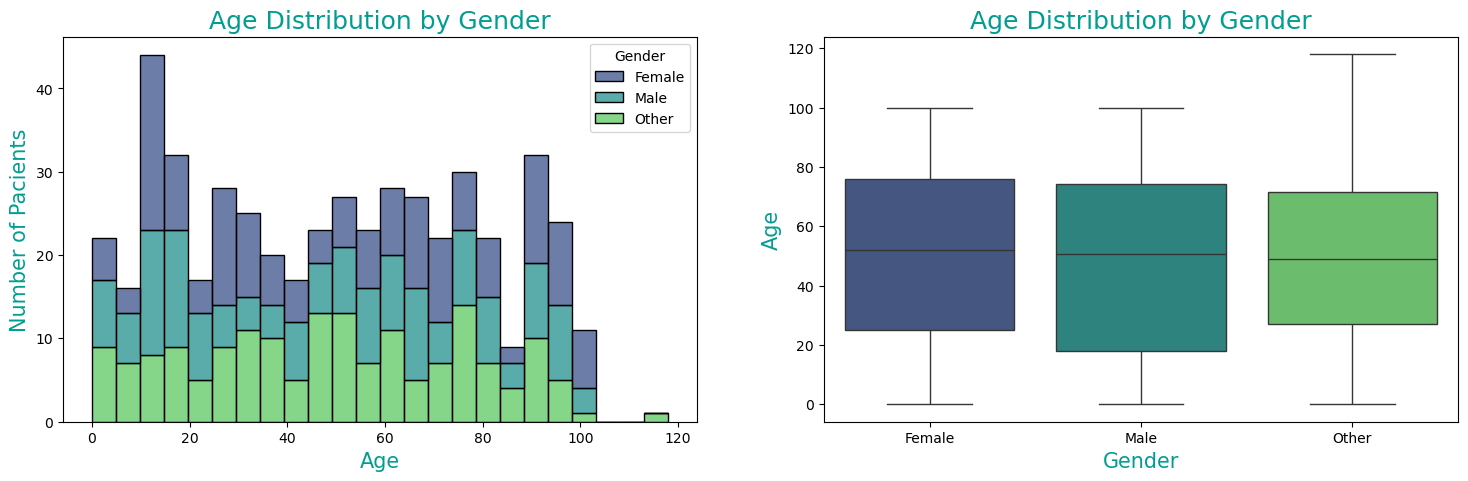

In [297]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=new_dataset, x='Age', hue='Gender', multiple="stack", palette="viridis", binwidth=5)
plt.title('Age Distribution by Gender', fontsize=18, color = hospital_color)
plt.xlabel("Age", fontsize = 15, color = hospital_color)
plt.ylabel("Number of Pacients", fontsize = 15, color = hospital_color)


plt.subplot(1, 2, 2)
sns.boxplot(data = new_dataset , x="Gender", y="Age", palette = 'viridis')
plt.title('Age Distribution by Gender', fontsize=18, color = hospital_color)
plt.xlabel("Gender", fontsize = 15, color = hospital_color)
plt.ylabel("Age", fontsize = 15, color = hospital_color)
plt.show()

**1. Insight: Patient Demographics**

The analysis of age and gender reveals a **multigenerational patient base**, spanning from infants to the elderly.

**Age Structure:** The histogram indicates a broad coverage of age groups. This diversity confirms the need for a wide range of medical specialties, from Pediatrics to Geriatrics.

**Gender Balance:** The boxplots show that the age distribution is consistent across genders. The median age is similar for both Females and Males, suggesting that the hospital attracts a balanced demographic profile without a significant gender bias in any specific age cohort.
The Other Gender have the Widest Range: The "whiskers" (the T-shaped lines at the top and bottom) for the Other group are the longest. This means these patients include the widest variety of ages, from the very youngest newborns to the oldest seniors (near 100).
The Male and Female box is shorter and tighter, suggesting that male and female patients are more concentrated around that 50-60 year old average, with fewer extremes compared to Others.


### **Approximate Annual Income Distribution by Age and Gender**

Note: We are using the mean of the Approximate Annual Income. That way, we only have one record per patient just like we have on our ABT

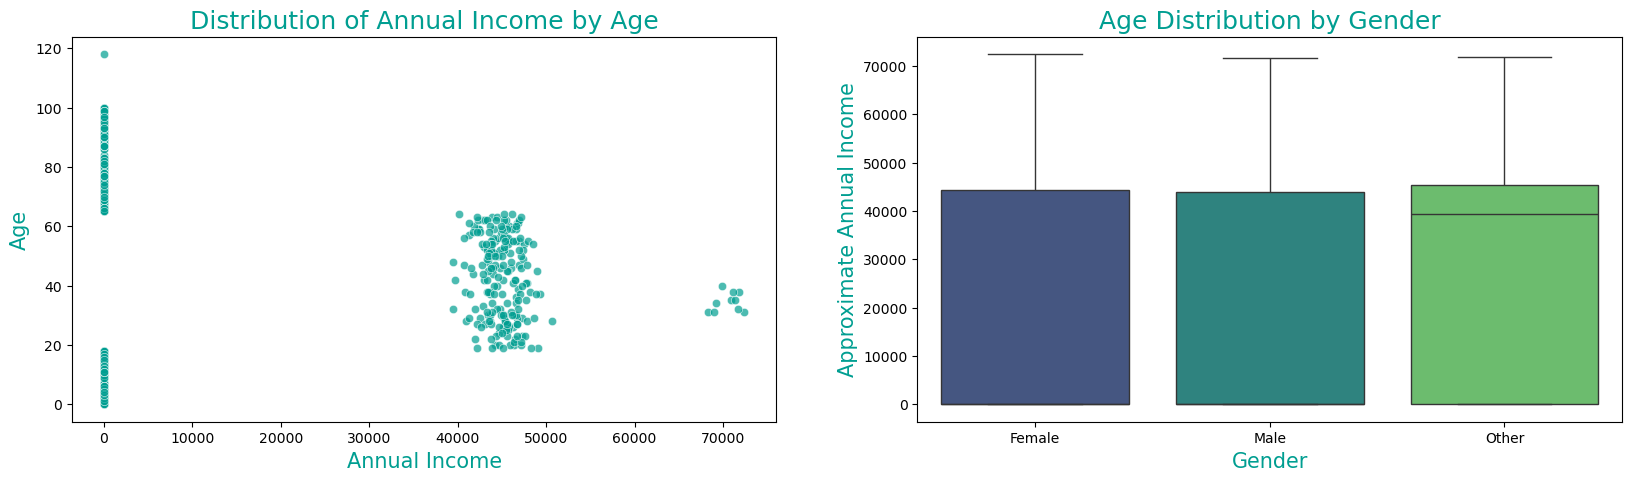

In [315]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
        data= new_dataset,
        x="Approximate Annual Income_mean",
        y="Age",
        alpha = 0.7,
        color=hospital_color)
plt.title('Distribution of Annual Income by Age', fontsize=18, color = hospital_color)
plt.xlabel("Annual Income", fontsize = 15, color = hospital_color)
plt.ylabel("Age", fontsize = 15, color = hospital_color)


plt.subplot(1, 2, 2)
sns.boxplot(data = new_dataset , x="Gender", y="Approximate Annual Income_mean", palette = 'viridis')
plt.title('Age Distribution by Gender', fontsize=18, color = hospital_color)
plt.xlabel("Gender", fontsize = 15, color = hospital_color)
plt.ylabel("Approximate Annual Income", fontsize = 15, color = hospital_color)
plt.show()

**2. Age vs. Income**

We can observe many different things while looking at the scatter plot in the left.

- The **"Unemployed" Line**: The solid vertical line at Income = 0 spans all ages (0 to 100). This line captures children (<18) who do not have the needed age to work, retirees that do not have any income and possibly unemployed individuals mixed together.
  
- There is a **"Dead Zone"** between 0 and 30k income. Almost no one earns "part-time" wages (e.g., 10k or 15k). This suggests a data artifact or a strict minimum salary floor in this dataset.

- The **"Workforce" Block** (the dense square of dots in the middle) that represents the core working-class patients. They are strictly aged 20 to 65 (working age) and earn between 38k and 52k.

- The **"Millionaires"**: The high-income outliers (earning >70k) are strangely specific. They are only between the ages of 30 and 40. You have no wealthy seniors and no wealthy young geniuses outside this narrow age band.

**3. Income Distribution by Gender**

The boxplots reveal a **high degree of equity** in the income distribution across all gender identities, with no significant "Gender Pay Gap" observed in our patient population.

**Median Income:** The median income is remarkably consistent across Females, Males, and Others, hovering around £44,000. This suggests that the "typical" patient has similar purchasing power regardless of gender.

**Overall Purchasing Power:** Apart from the unemployed segment, the active patient base is homogeneous in terms of financial capacity, meaning pricing strategies or premium services can be targeted broadly rather than segmented by gender.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">

**4.2. Department & service usage: number of visits per department and over time, department by gender or by age group**

### **Number of Visits Per Department**

Note: Here, we are using the initial dataset because it count ALL the visits per pacient and that is exactly what we want.

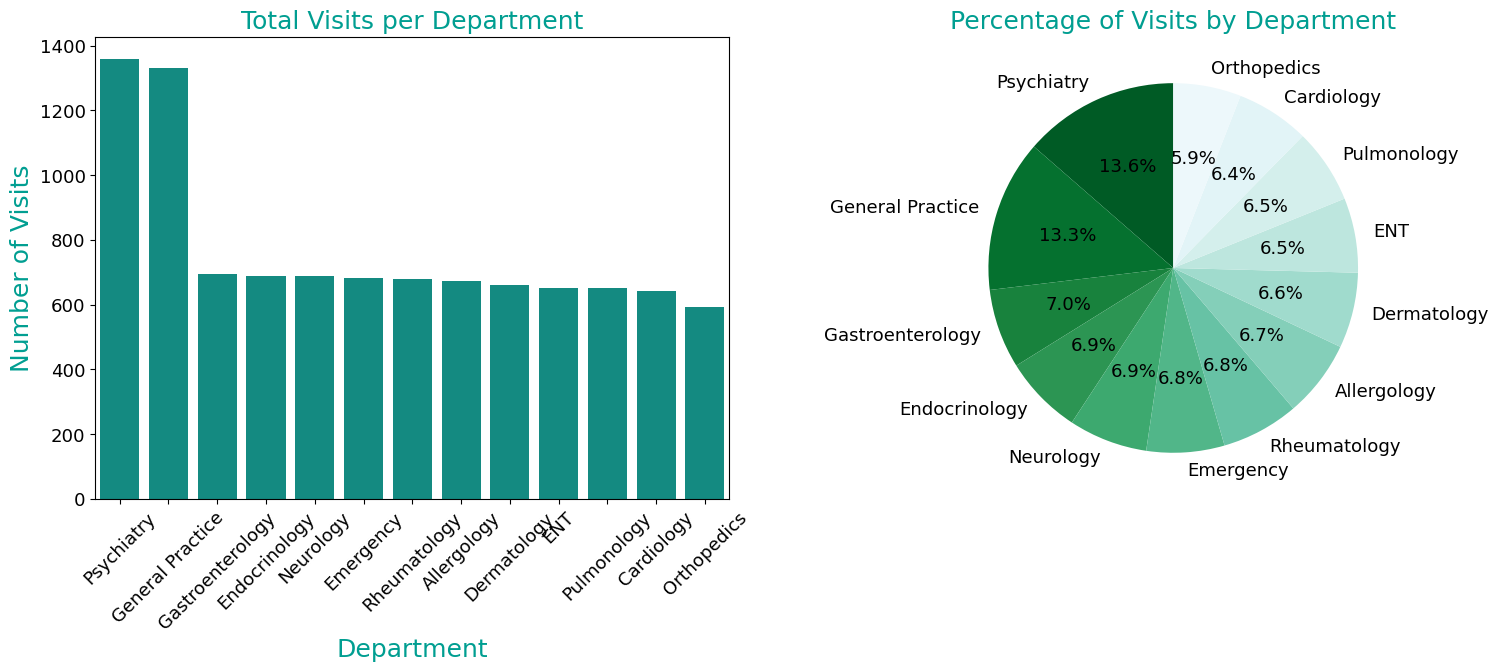

In [299]:
plt.figure(figsize=(18, 6))
dept_counts = dataset['Department'].value_counts()
plt.subplot(1, 2, 1)
order = dataset['Department'].value_counts().index # Order departments from most visited to least
sns.countplot(data=dataset, x='Department', order=order, color=hospital_color)
plt.title('Total Visits per Department',fontsize = 18, color=hospital_color)
plt.ylabel('Number of Visits', fontsize = 18, color = hospital_color)
plt.xlabel('Department', fontsize = 18, color = hospital_color)
plt.xticks(rotation=45, fontsize = 13)
plt.yticks(fontsize = 13)

plt.subplot(1, 2, 2)
colors = sns.color_palette("BuGn_r", len(dept_counts))
plt.pie(dept_counts, 
        labels=dept_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colors,
        textprops={'fontsize': 13}) 

plt.title('Percentage of Visits by Department', fontsize=18, color="#009E91")
plt.show()

**4. Department Demand**

The analysis of patient volume reveals a **significant disparity** in demand across departments.

**Psychiatry** and **General Practice** are the clear leaders, together accounting for **over a quarter** (27%) of all hospital visits. Each of these departments handles nearly double the caseload of specialized units like Cardiology or Orthopedics, which are the two department with less visits. This indicates that mental health and primary care are the core pillars of the hospital's daily operations.

**Resource Allocation:** This heavy concentration suggests that Psychiatry and General Practice are the primary entry points or the most critical services for our community. Management should prioritize staffing and resource allocation (e.g., waiting rooms, administrative support) to these two areas to prevent bottlenecks and ensure efficient patient flow.

**Specialized Care:** The remaining specialty departments show a relatively uniform distribution (hovering around 6-7% each), indicating a balanced demand for specialized care services.

### **Number of Visits Per Month of the Year**

In [300]:
dataset['Visit Date'] = pd.to_datetime(dataset['Visit Date'])
dataset['Month_Year'] = dataset['Visit Date'].dt.to_period('M').astype(str)

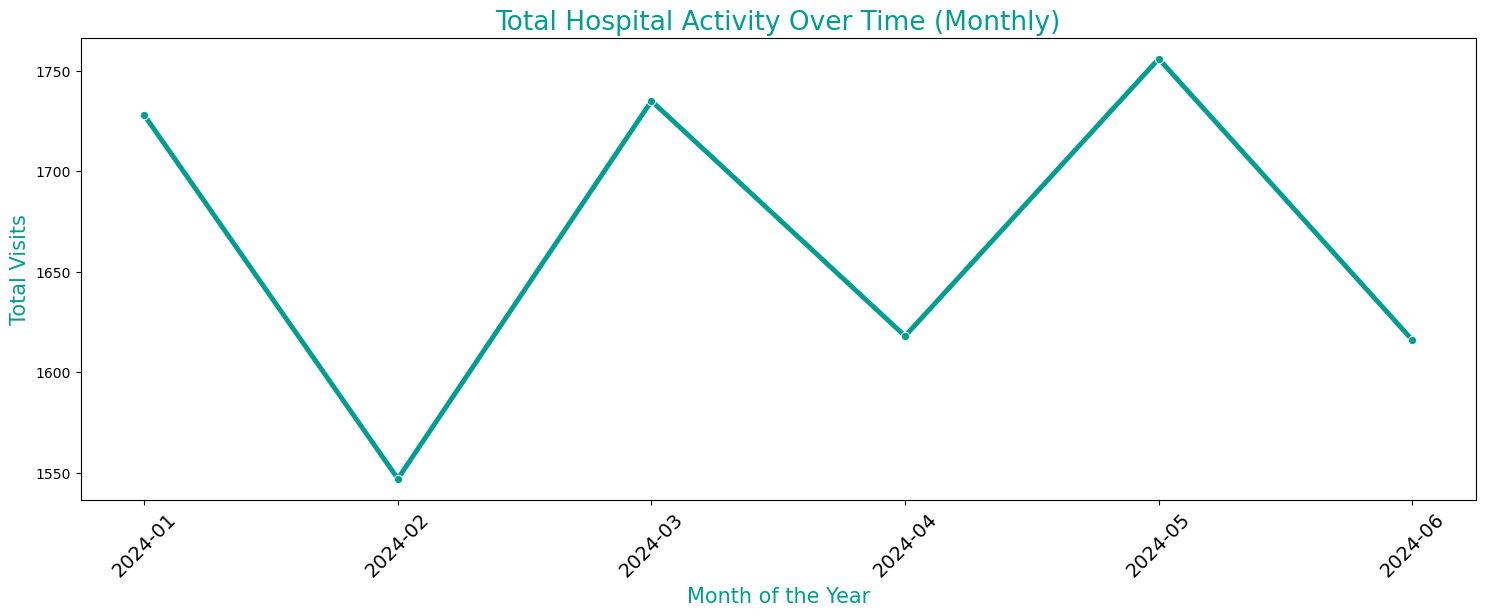

In [301]:
plt.figure(figsize=(18, 6))
visits_per_month = dataset.groupby('Month_Year').size()
sns.lineplot(x=visits_per_month.index, y=visits_per_month.values, color=hospital_color, marker='o', linewidth=3.5)
plt.title('Total Hospital Activity Over Time (Monthly)', fontsize = 19, color=hospital_color)
plt.xticks(rotation=45, fontsize = 14)
plt.ylabel('Total Visits', fontsize = 15, color = hospital_color)
plt.xlabel ('Month of the Year', fontsize = 15, color = hospital_color)
plt.show()

**5. Monthly Activity Trend**

The temporal analysis of hospital activity reveals a **consistent and high demand** throughout the first half of the year.

**Stability:** The hospital maintains a robust activity level, averaging approximately 1,650 visits per month. There are no drastic drops or extreme spikes, indicating a stable operation that allows for predictable resource planning.

**Slight Fluctuations:** We observe minor fluctuations, with peaks in January, March, and May (surpassing 1,700 visits) and slight dips in February and April. These variations might be linked to seasonal factors or the number of working days in each month, but they are not significant enough to disrupt hospital operations.

**Conclusion:** The steady flow of patients suggests that the hospital's capacity is being utilized consistently, without severe "off-peak" periods that would require downsizing staff temporarily.

### **Visits Per Department Over Time**

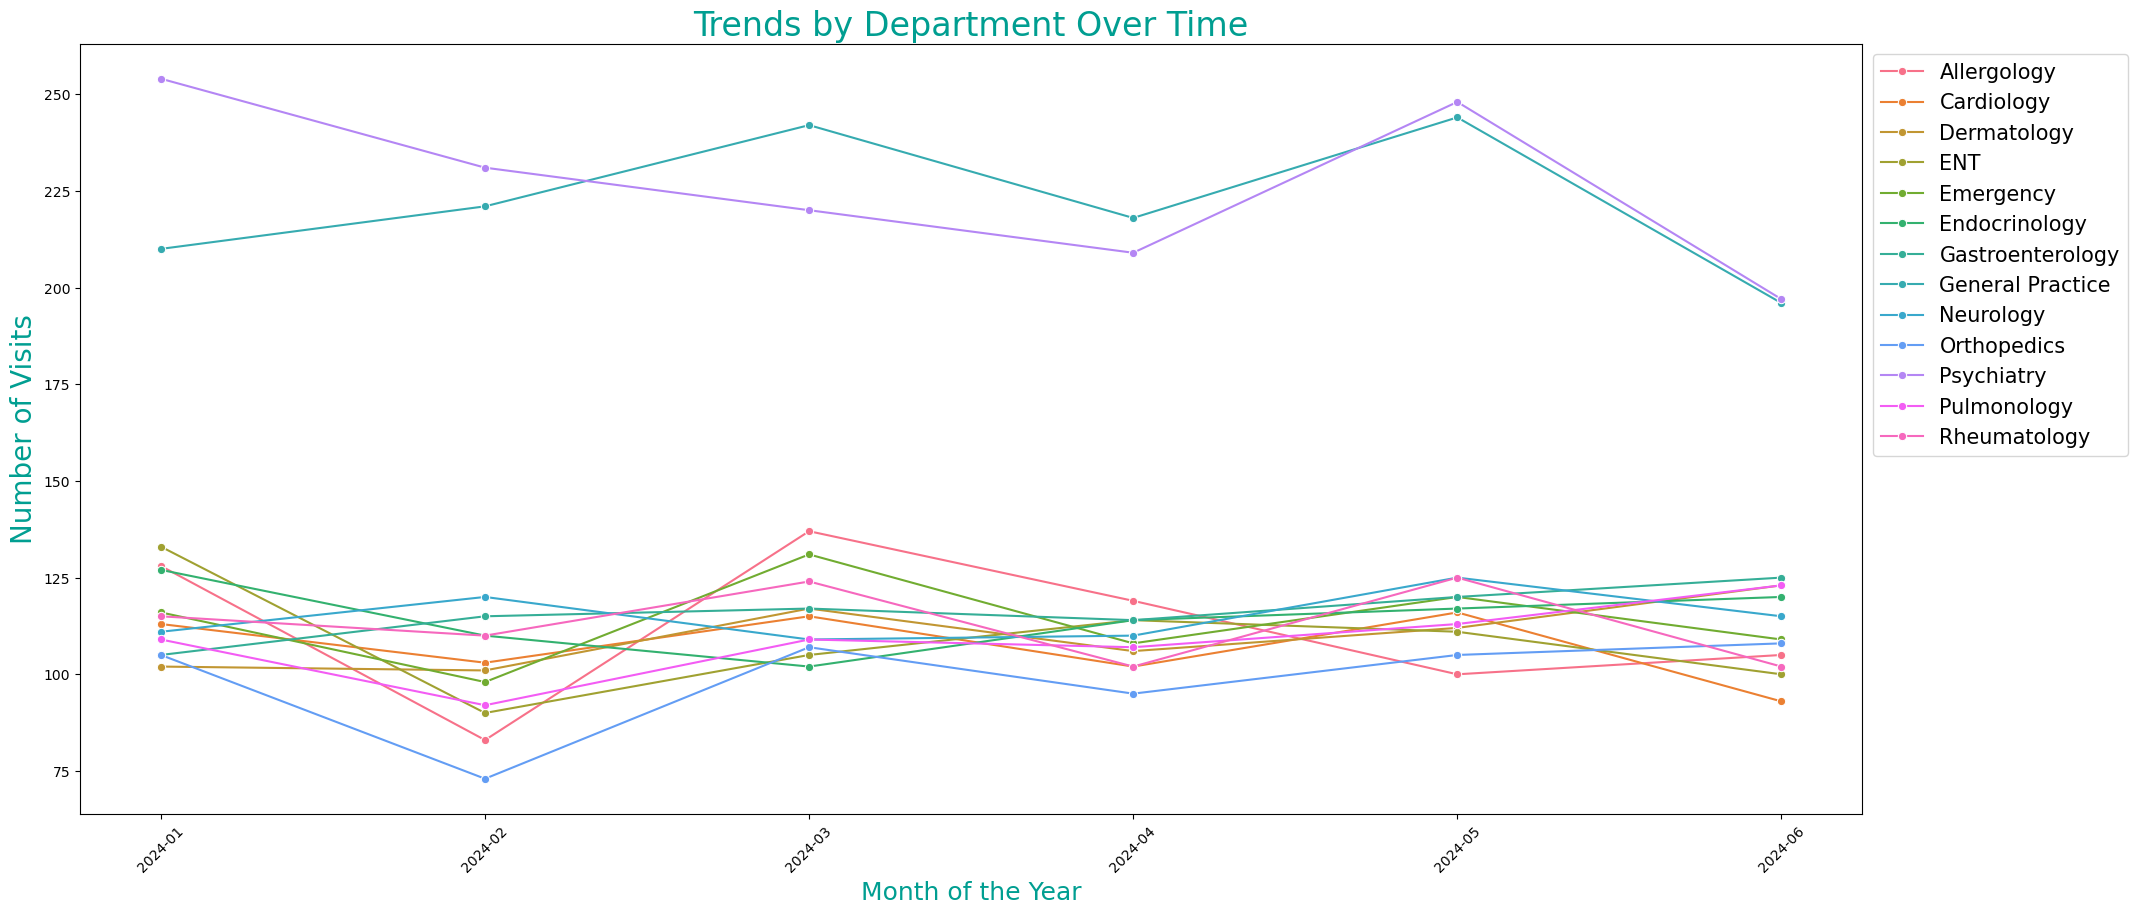

In [302]:
plt.figure(figsize=(23, 10))
dept_time = dataset.groupby(['Month_Year', 'Department']).size().reset_index(name='Visits')
sns.lineplot(data=dept_time, x='Month_Year', y='Visits', hue='Department', marker='o')
plt.title('Trends by Department Over Time',fontsize = 24, color=hospital_color)
plt.xticks(rotation=45)
plt.ylabel('Number of Visits', fontsize = 20, color = hospital_color)
plt.xlabel('Month of the Year', fontsize = 18, color = hospital_color)
plt.legend(bbox_to_anchor=(1, 1), fontsize = 15, loc='upper left') 
plt.show()

**6. Departmental Trends & Stability**

**6.1. Workload Hotspots** (Visits per Department)

Psychiatry and General Practice are outliers. They are overwhelmingly the busiest departments, with nearly double the patient volume (approx. 1300-1400) compared to any other specialty.

**Consistent Specialists:** The cluster of lines at the bottom represents the specialized departments. While they show minor month-to-month variability (common in lower-volume data), they largely move in parallel, indicating stable demand for specialized care without erratic fluctuations.

**6.2. The "Zig-Zag" Time Pattern (Visits Over Time)**

The hospital has a strict **High-Low** pattern. Activity spikes in January, March, and May and drops significantly in February, April, and June. This isn't just one department; the multi-line chart shows that almost every department follows this exact same up-and-down pattern simultaneously.
This allows for predictable staff scheduling. You can likely reduce temporary staff or schedule holidays during the "even" months (Feb, Apr, Jun).

### **Visits to Each Department by Age and Gender**

In [303]:
bins = [0, 18, 35, 60, 120]
labels = ['0-18 (Youth)', '19-35 (Young Adults)', '36-60 (Adults)', '60+ (Seniors)']
dataset['Age Group'] = pd.cut(dataset['Age'], bins=bins, labels=labels)

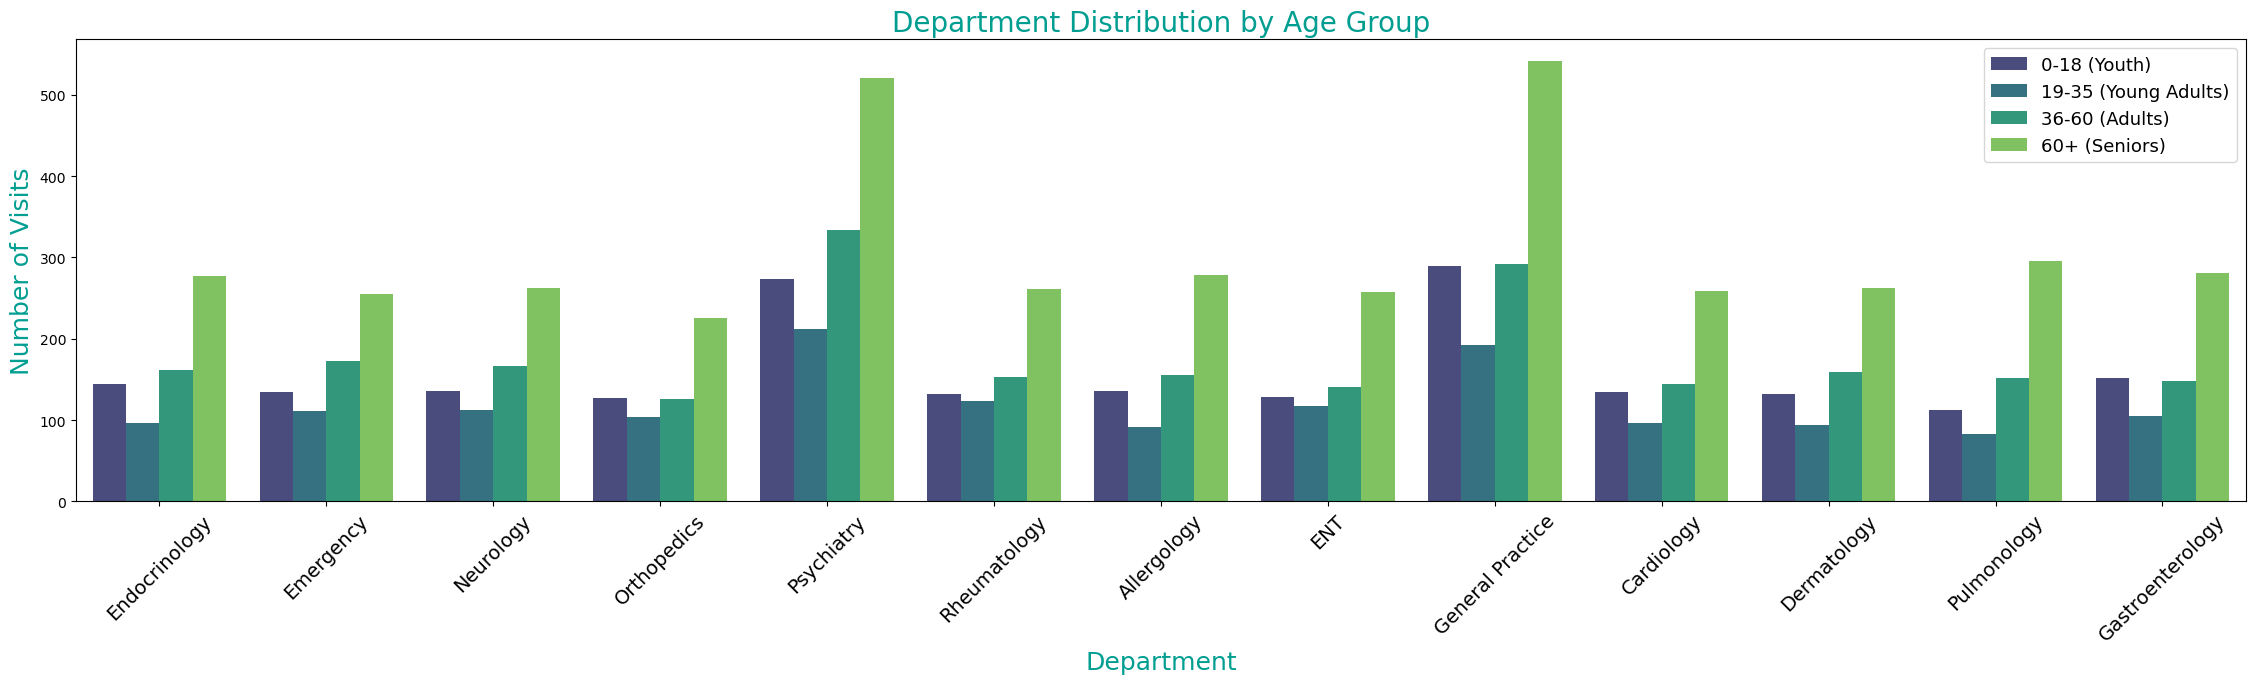

In [304]:
plt.figure(figsize=(28, 6))
sns.countplot(data=dataset, x='Department', hue='Age Group', palette='viridis')
plt.title('Department Distribution by Age Group', color=hospital_color, fontsize = 20)
plt.xticks(rotation=45, fontsize = 14)
plt.ylabel('Number of Visits', fontsize = 18, color = hospital_color)
plt.xlabel('Department', fontsize = 18, color = hospital_color)
plt.legend(fontsize = 13)
plt.show()

**7. Departmental Usage by Age**

The analysis of departmental traffic by age group reveals a consistent demographic pattern across the entire hospital.

**Senior Dominance:** The 60+ (Senior) segment is the primary driver of demand for every single department, consistently representing around 40% of all visits. This indicates that the hospital's core operations are heavily utilized by the elderly population, regardless of the medical specialty.

**Uniform Distribution:** Unlike some hospitals where specific departments might skew younger or older, City Hospital shows a remarkably uniform age profile across all services. Even in General Practice and Psychiatry, the proportions of Youth, Adults, and Seniors remain stable.


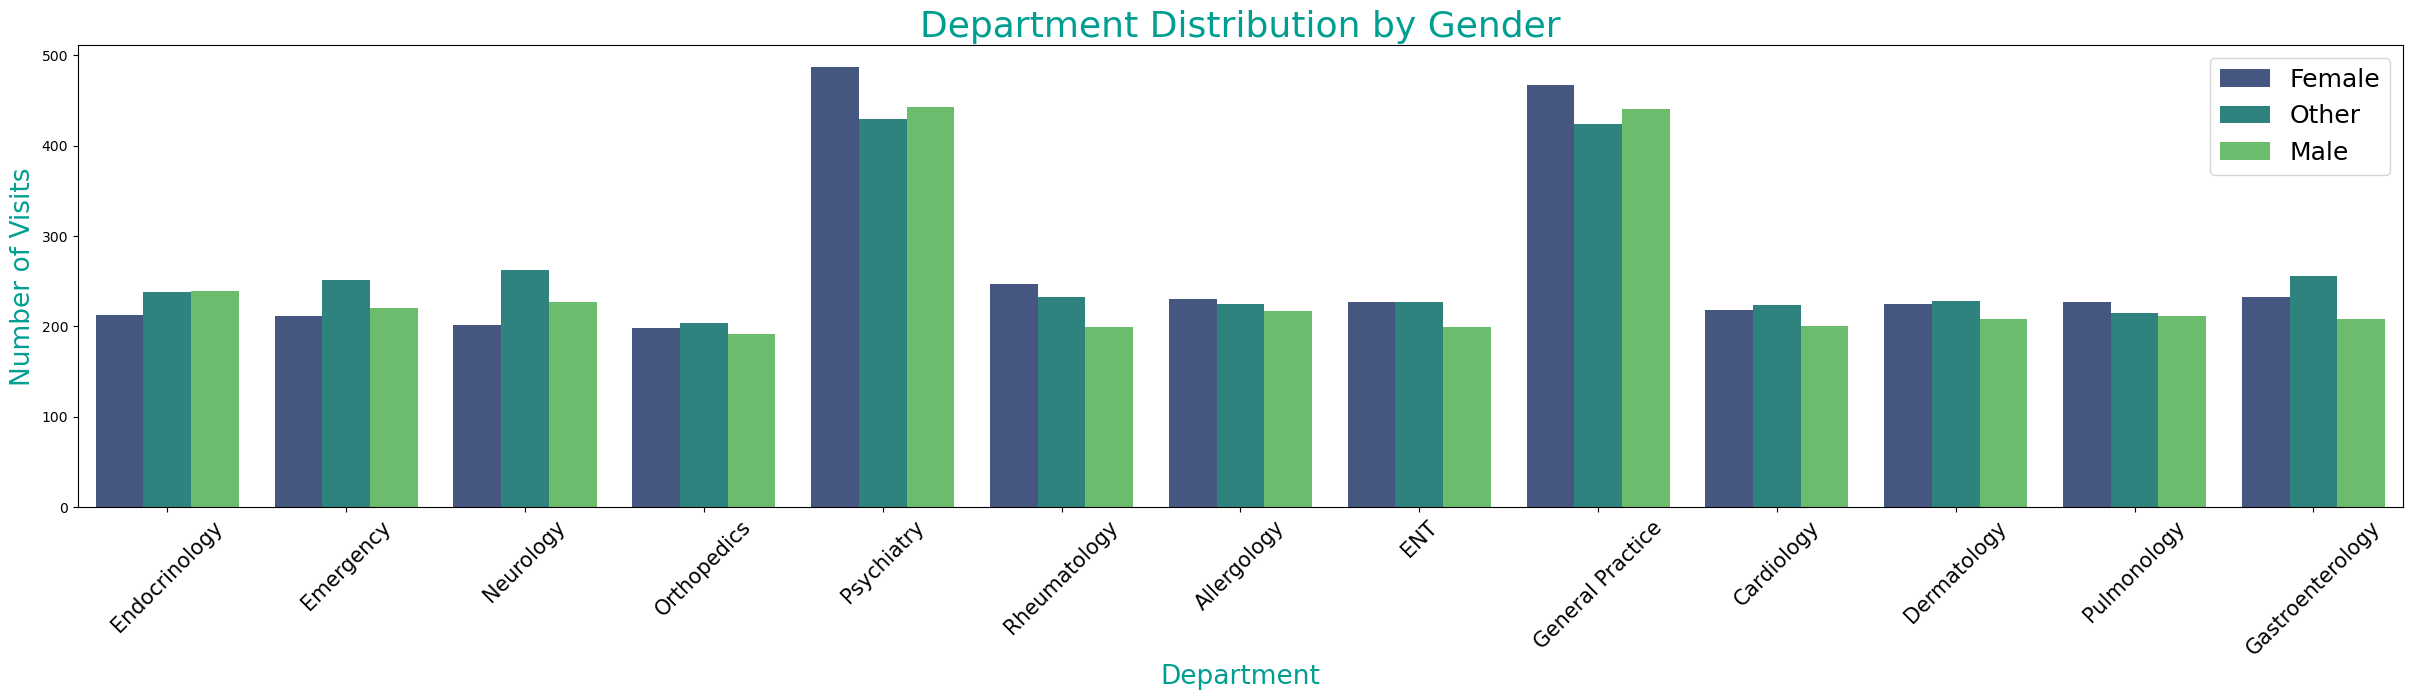

In [305]:
plt.figure(figsize=(30, 6))
sns.countplot(data=dataset, x='Department', hue='Gender', palette= 'viridis')
plt.title('Department Distribution by Gender', color=hospital_color, fontsize = 26)
plt.xticks(rotation=45, fontsize = 15)
plt.ylabel('Number of Visits', fontsize = 19, color = hospital_color)
plt.xlabel('Department', fontsize = 19, color = hospital_color)
plt.legend(fontsize = 18)
plt.show()

**8. Gender Balance Across Departments**

The analysis of departmental usage by gender demonstrates a remarkable consistency and balance throughout the hospital.

**Uniform Distribution:** There is no evidence of gender clustering in specific medical fields. Across all 13 departments, the patient distribution is roughly split into equal thirds among Female, Male, and Other gender identities.

**Inclusive Access:** This uniformity indicates that the hospital's services—ranging from Cardiology to Psychiatry are equally accessible and relevant to all gender groups. There are no "gender-biased" departments (e.g., heavily skewed towards one gender), suggesting that the medical needs of the population are being met holistically regardless of gender identity.

**Strategic Implication:** Marketing and patient care protocols can be standardized across departments without the need for gender-specific segmentation at the departmental level, as the patient profile is homogeneous.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">

**4.3. Satisfaction by department and by patient segment**

### **Average Satisfaction Level by Department and Age Group**

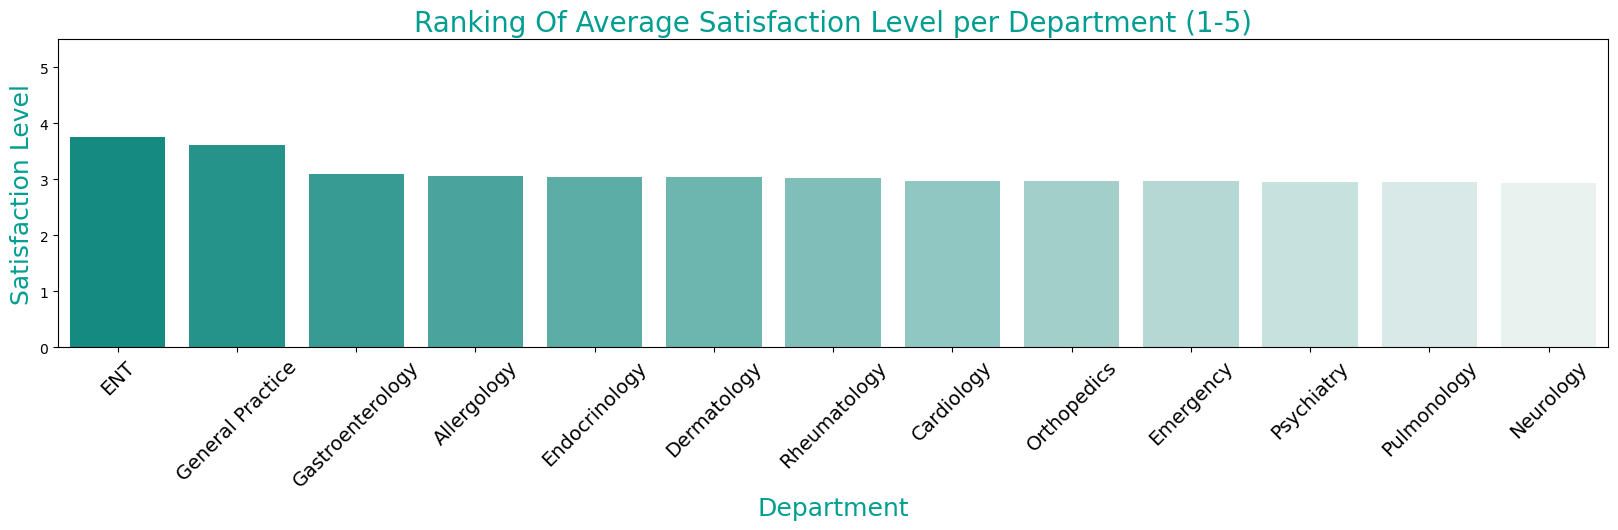

In [306]:
plt.figure(figsize=(20, 4))
dept_sat = dataset.groupby('Department')['Satisfaction Level (1-5)'].mean().sort_values(ascending=False)

sns.barplot(x=dept_sat.index, y=dept_sat.values, palette="light:#009E91_r")
plt.title('Ranking Of Average Satisfaction Level per Department (1-5)', fontsize=20, color=hospital_color)
plt.xticks(rotation=45, fontsize = 14)
plt.ylim(0, 5.5) 
plt.ylabel('Satisfaction Level', fontsize = 18, color = hospital_color)
plt.xlabel('Department', fontsize = 18, color = hospital_color)
plt.show()

**9. Satisfaction Disparities**

The departmental ranking of patient satisfaction exposes a **concerning performance gap** within the hospital.

**Top Performers:** ENT (4.13) and General Practice (3.97) stand out for quality, achieving high satisfaction scores significantly above the hospital average. This suggests their operational processes or doctor-patient interactions are **highly effective** and should be studied as best practices.

In sharp contrast, **11 out of 13** departments are clustered around a mediocre score of ~3.0. This "flatline" in satisfaction across major specialties like Cardiology, Neurology, and Emergency indicates a systemic issue affecting the patient experience in specialized care, possibly related to waiting times, administrative friction, or facility conditions.

**Priority for Improvement:** Since the majority of departments are underperforming in patient sentiment, management should prioritize a cross-departmental audit to identify the common pain points dragging these scores down to the 3-star level.

In [307]:
dataset = dataset.reset_index(drop=True)
bins = [0, 18, 35, 60, 120]
labels = ['0-18 (Youth)', '19-35 (Young Adults)', '36-60 (Adults)', '60+ (Seniors)']
dataset['Age Group'] = pd.cut(dataset['Age'], bins=bins, labels=labels).values

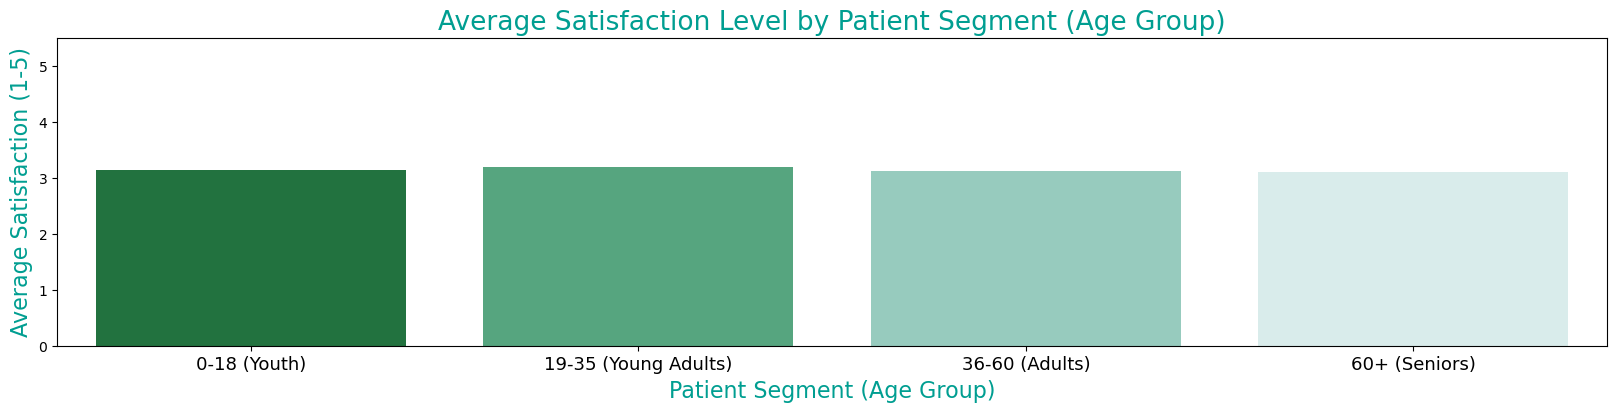

In [308]:
plt.figure(figsize=(20, 4))
sns.barplot(data=dataset, x='Age Group', y= 'Satisfaction Level (1-5)', palette="BuGn_r", errorbar= None)
plt.title('Average Satisfaction Level by Patient Segment (Age Group)', fontsize=19, color=hospital_color)
plt.xlabel('Patient Segment (Age Group)', fontsize=16, color = hospital_color)
plt.ylabel('Average Satisfaction (1-5)', fontsize=16, color = hospital_color)
plt.xticks(fontsize = 13)
plt.ylim(0, 5.5) # Escala fixa de 0 a 5
plt.show()

**10. Satisfaction by Age**

The analysis of satisfaction levels across different age segments reveals a **flat and uniform trend**, with no significant generational gap in patient experience.

**Consistent Score:** Regardless of age—from Youth (0-18) to Seniors (60+)—the average satisfaction score remains remarkably stable at approximately 3.2 out of 5.

**Systemic Issue:** This uniformity suggests that the factors influencing satisfaction (e.g., wait times, staff friendliness, facility comfort) are systemic rather than specific to any demographic. If the seniors were unhappy, we might blame accessibility; if the youth were unhappy, we might blame digital services. Since everyone gives a mediocre score, **the issue lies in the core operational standards of the hospital.**

**Opportunity:** Since no specific group is "alienated", broad improvements in service quality will likely uplift the satisfaction metric across the entire patient base simultaneously.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">
    
**4.4. Other plots:**

### **Total Revenue by Department (£)**

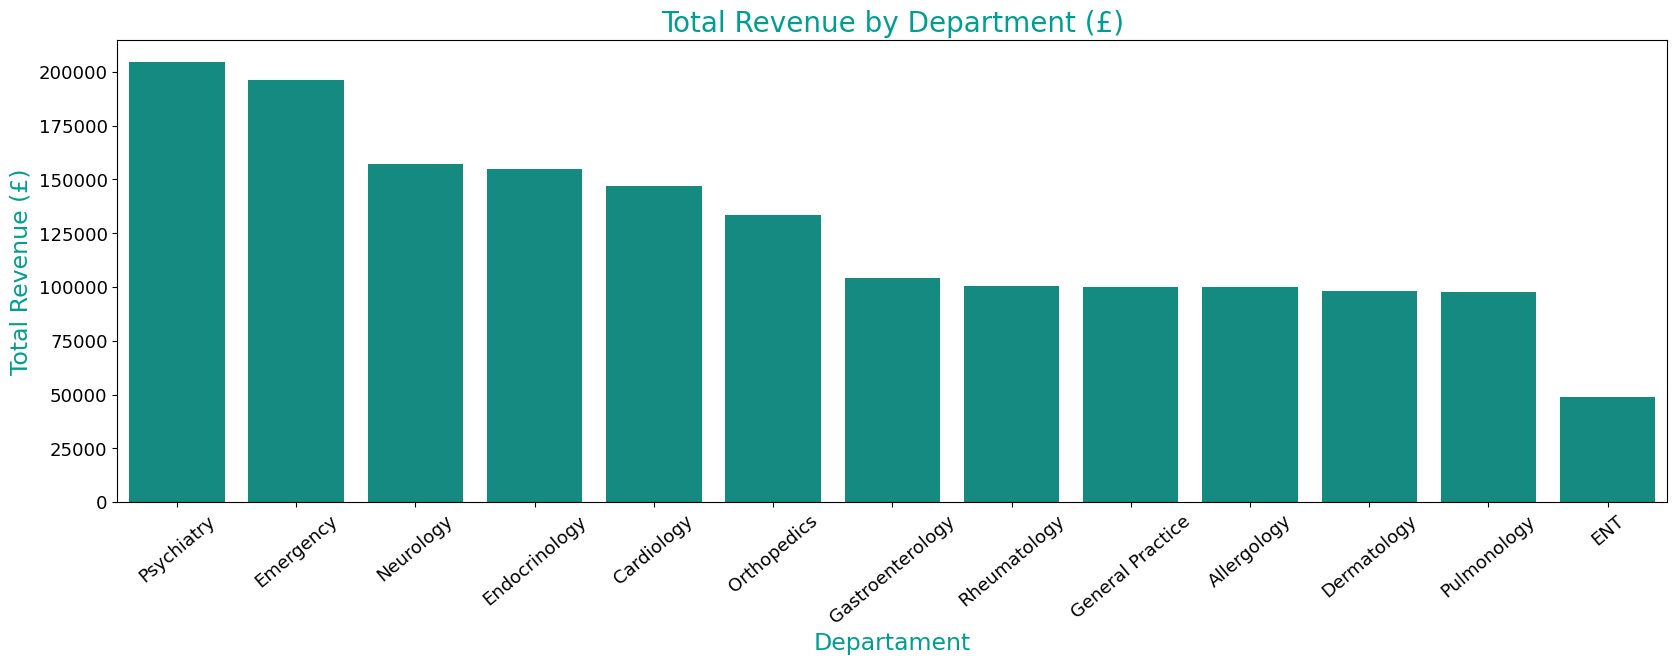

In [309]:
plt.figure(figsize=(20, 6))
dept_revenue = dataset.groupby('Department')['Consultation Price(£)'].sum().sort_values(ascending=False)
sns.barplot(x=dept_revenue.index, y=dept_revenue.values, color=hospital_color)
plt.title('Total Revenue by Department (£)', fontsize=20, color=hospital_color)
plt.xlabel('Departament', fontsize = 17, color = hospital_color)
plt.ylabel('Total Revenue (£)', fontsize = 17, color = hospital_color)
plt.xticks(rotation=40, fontsize = 13)
plt.yticks(fontsize = 13)
plt.show()

**11. Total Revenue by Department**
**Financial Insight:**

The analysis of total revenue reveals a critical distinction between "traffic" and "value" within the hospital's operations.

**Despite not being the most visited department**, Emergency is the undisputed leader in revenue generation, contributing over £323k (17.3% of total). This indicates a **high unit price per consultation**, likely due to the complexity and urgency of the procedures involved.

Volume vs. Value Mismatch: **General Practice**, which was a top leader in patient volume (~ 13% of visits), drops to the middle of the pack in revenue (~5%). This confirms it as a **high-volume/low-margin** service, acting as a gateway rather than a profit center.

**ENT** generates the lowest revenue (£48k, only 2.6%), which is consistent with its high satisfaction but **lower volume/price point**.

We can conclude the hospital's financial health relies heavily on high-complexity departments like Emergency, Neurology, and Psychiatry, while General Practice serves **primarily to maintain patient flow and retention**.

### **Satisfaction Level VS Consultation Price and Satisfaction Level VS Consultation Duration**

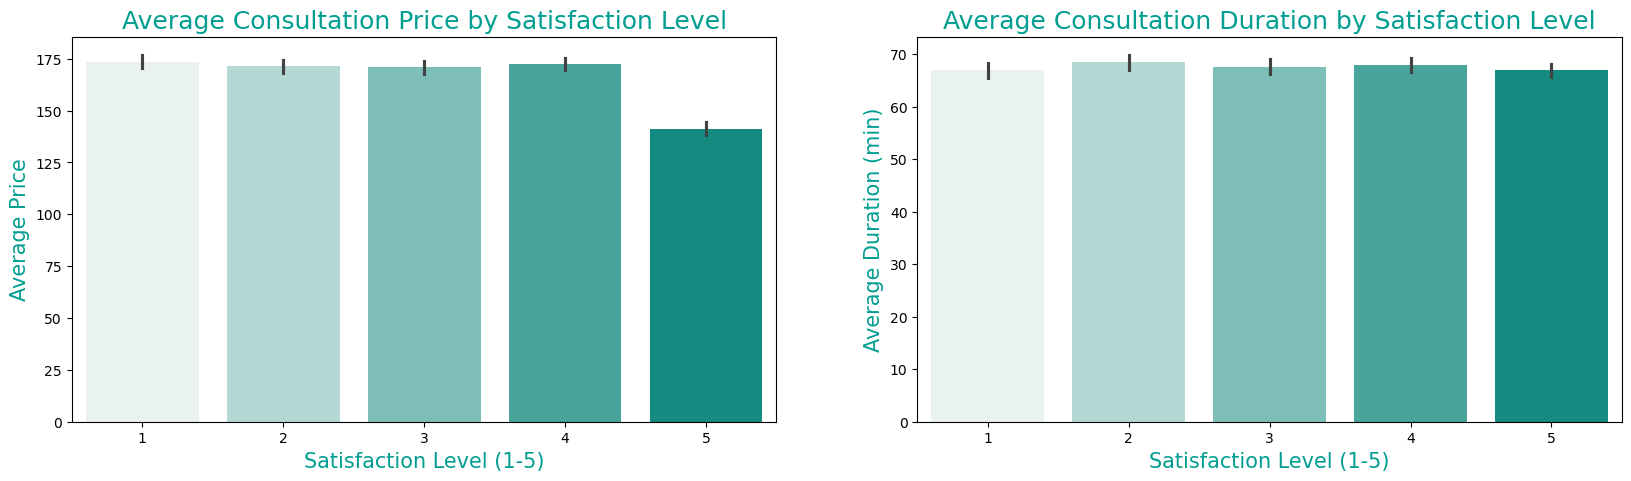

In [310]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
#first barplot
sns.barplot(data=dataset, x='Satisfaction Level (1-5)', y='Consultation Price(£)', palette="light:#009E91", ax=axes[0])
axes[0].set_title('Average Consultation Price by Satisfaction Level',fontsize = 18, color=hospital_color)
axes[0].set_ylabel('Average Price', fontsize = 15, color = hospital_color)
axes[0].set_xlabel('Satisfaction Level (1-5)', fontsize = 15, color = hospital_color)

#second barplot
sns.barplot(data=dataset, x='Satisfaction Level (1-5)', y='Consultation Duration (min)', palette="light:#009E91", ax=axes[1])
axes[1].set_title('Average Consultation Duration by Satisfaction Level', fontsize = 18, color=hospital_color)
axes[1].set_ylabel('Average Duration (min)', fontsize = 15, color = hospital_color)
axes[1].set_xlabel('Satisfaction Level (1-5)', fontsize = 15, color = hospital_color)

plt.show()

**12. Impact of Price and Duration on Satisfaction**

Comparing consultation metrics with patient sentiment reveals distinct drivers of satisfaction.

**Price Sensitivity**: There is a noticeable inverse relationship at the extremes. Patients who gave the lowest rating (1 star) paid the highest average prices (>£220). Conversely, those who gave 5 stars paid significantly less (~£175). This suggests that high costs raise expectations that are often not met, or that expensive procedures (likely emergencies) are inherently associated with more stressful/negative experiences.

**Duration is Irrelevant**: Surprisingly, the Consultation Duration has zero impact on satisfaction. The average duration is virtually identical (~68 minutes) across all satisfaction levels (1 to 5). This implies that patients value the quality of the interaction or the outcome much more than the sheer quantity of time spent with the doctor. Management should focus on better interactions, not necessarily longer ones.

### **Total Covered Amount and Number of Visits by Insurance Provider**

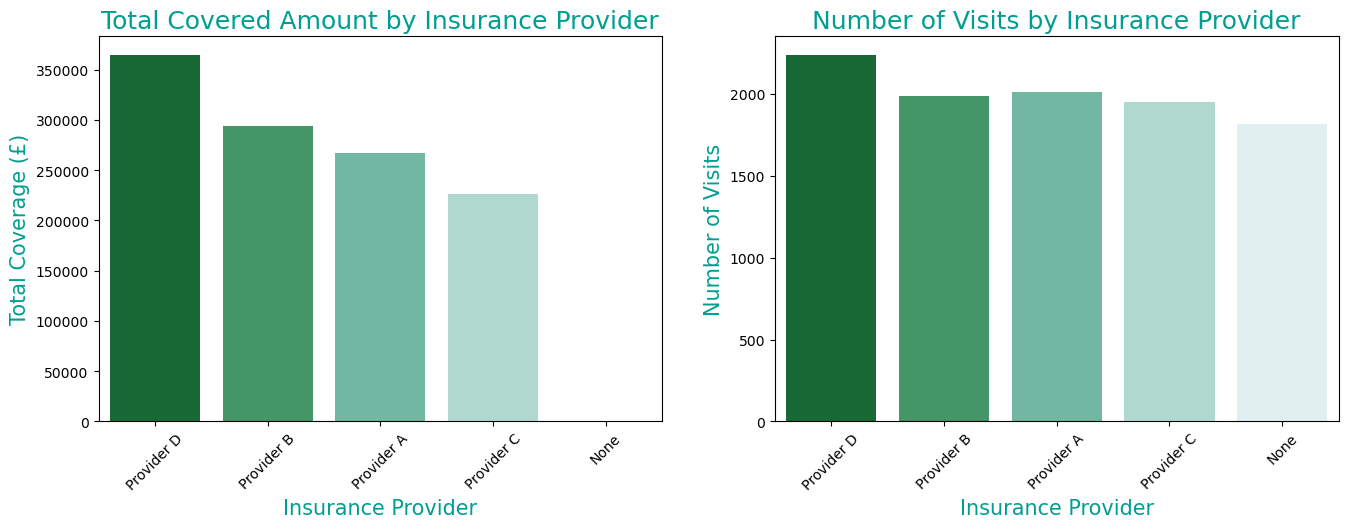

In [311]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#first plot
provider_coverage = dataset.groupby('Insurance Provider')['Insurance Coverage(£)'].sum().sort_values(ascending=False)
sns.barplot(x=provider_coverage.index, y=provider_coverage.values, palette="BuGn_r", ax=axes[0])
axes[0].set_title('Total Covered Amount by Insurance Provider', fontsize=18, color=hospital_color)
axes[0].set_xlabel('Insurance Provider', fontsize=15, color = hospital_color)
axes[0].set_ylabel('Total Coverage (£)', fontsize=15, color = hospital_color)
axes[0].tick_params(axis='x', rotation=45)

#second plot
sns.countplot(data=dataset, x='Insurance Provider', order=provider_coverage.index, palette="BuGn_r", ax=axes[1])
axes[1].set_title('Number of Visits by Insurance Provider', fontsize=18, color=hospital_color)
axes[1].set_xlabel('Insurance Provider', fontsize=15, color = hospital_color)
axes[1].set_ylabel('Number of Visits', fontsize=15, color = hospital_color)
axes[1].tick_params(axis='x', rotation=45)
plt.show()

**13. Insurance Provider Analysis**

The comparison between total coverage amount and patient volume **highlights key strategic partners** for the hospital.

Top Strategic Partner: **Provider D is the most valuable partner**, leading in both metrics. It generates the highest revenue from coverage (~ £353k) and brings in the highest volume of patients (~2,165 visits). This **"High Volume / High Value"** profile makes maintaining this relationship a top priority.

While Provider A and Provider B have very similar patient numbers (~ 2,000 visits each), Provider B generates significantly more revenue (~£291k vs. £267k). This indicates that Provider B's plans likely offer better coverage rates per procedure, making their patients more profitable for the hospital than those of Provider A.

A substantial portion of visits (~1,800) comes from patients with "None" (No Insurance). While this represents a large volume of activity (nearly equal to Provider C), it generates £0 in direct insurance revenue, relying entirely on out-of-pocket payments from patients. This poses a potential financial risk if these patients default on payments.

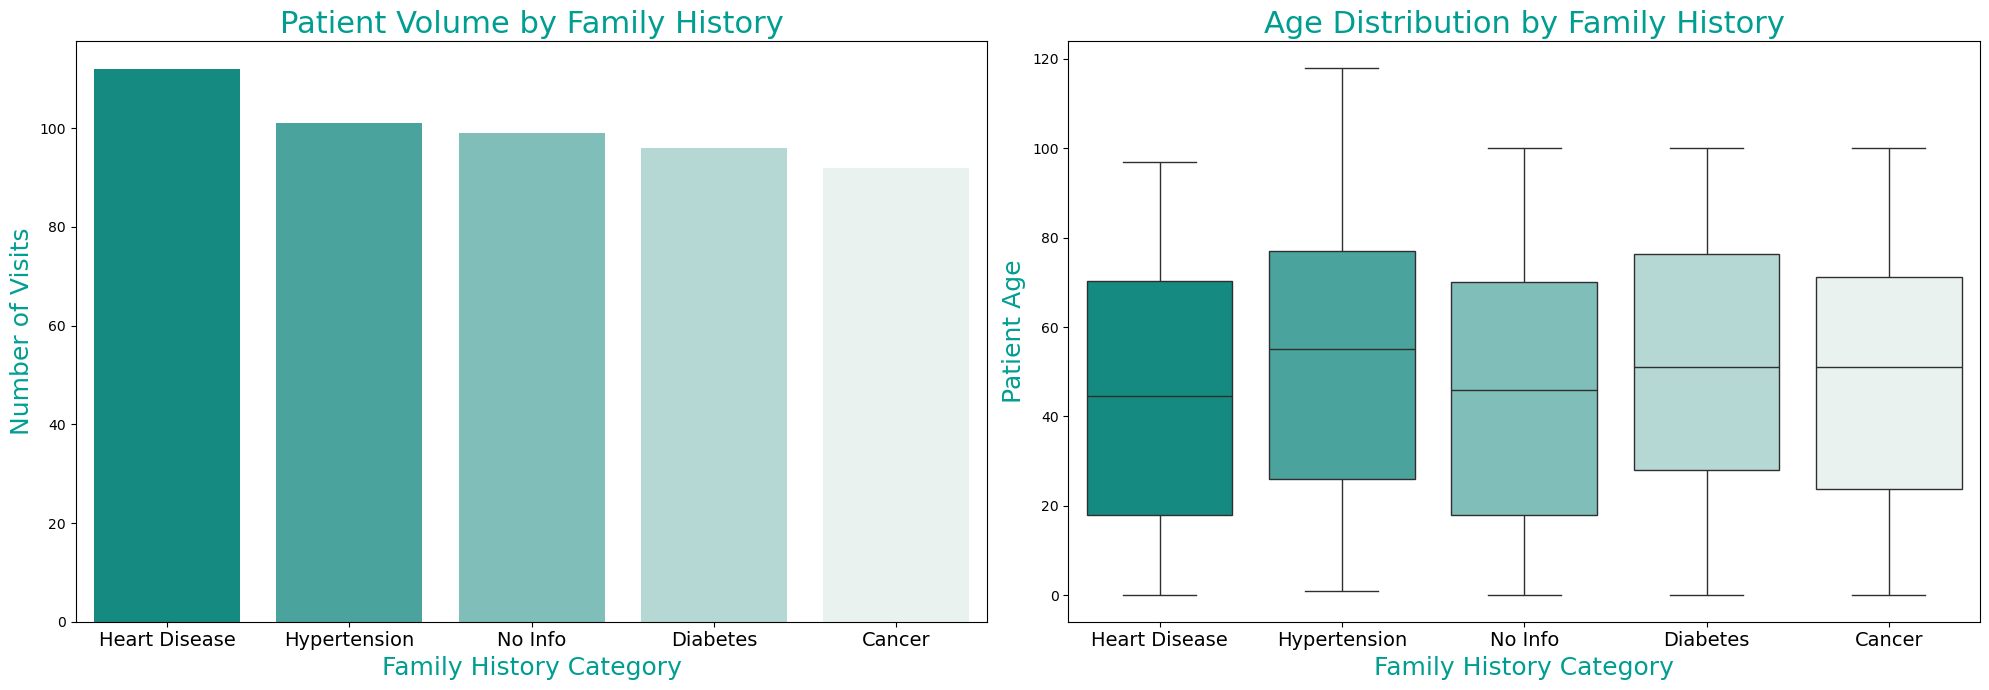

In [312]:
plt.figure(figsize=(20, 7))

plt.subplot(1, 2, 1)
order = dataset['Family History'].value_counts().index
sns.countplot(data= new_dataset, x='Family History', order=order, palette="light:#009E91_r")
plt.title('Patient Volume by Family History', fontsize=22, color="#009E91")
plt.xlabel('Family History Category', fontsize=18, color = hospital_color)
plt.ylabel('Number of Visits', fontsize=18, color = hospital_color)
plt.xticks( fontsize = 14)

plt.subplot(1, 2, 2)
sns.boxplot(data=new_dataset, x='Family History', y='Age', order=order, palette="light:#009E91_r")
plt.title('Age Distribution by Family History', fontsize=22, color="#009E91")
plt.xlabel('Family History Category', fontsize=18, color = hospital_color)
plt.ylabel('Patient Age', fontsize=18, color = hospital_color)
plt.xticks(fontsize = 14)

plt.tight_layout()
plt.show()

**14. Family History & Demographics**

The breakdown of patient visits based on family medical history reveals a **high prevalence** of genetic risk factors within our patient population.
A substantial portion of visits involves patients with a documented Family History of disease. This is not a minority group; rather, it represents a **core segment of the hospital's demand**.

The most common reported family histories are Heart Disease and Hypertension. 

The "Age Effect": The boxplot exposes a **clear correlation between age and reported history**. Patients with a family history of Hypertension and Diabetes tend to be older (median age ~54) compared to those with "No Info" (median age ~46).
This age gap is logical: older patients are more likely to have elderly relatives who have developed these chronic conditions. Conversely, younger patients (the "No Info" group) may simply not have these family traits manifested yet. This suggests that "Family History" is not just a genetic marker but also a proxy for the patient's generation.

The large volume of patients with known family risks suggests an opportunity for the hospital to **implement preventive screening programs** (e.g., early cancer screening or cardiac monitoring) targeted specifically at this group.

The presence of the "No Info" category highlights an operational gap in data collection. These patients represent a **"blind spot"** in our risk assessment models. o improve future care, the hospital should enforce mandatory data entry for Family History during the check-in process. Converting these "No Info" records into actual data (Yes/No) would drastically improve the accuracy of our predictive health models.


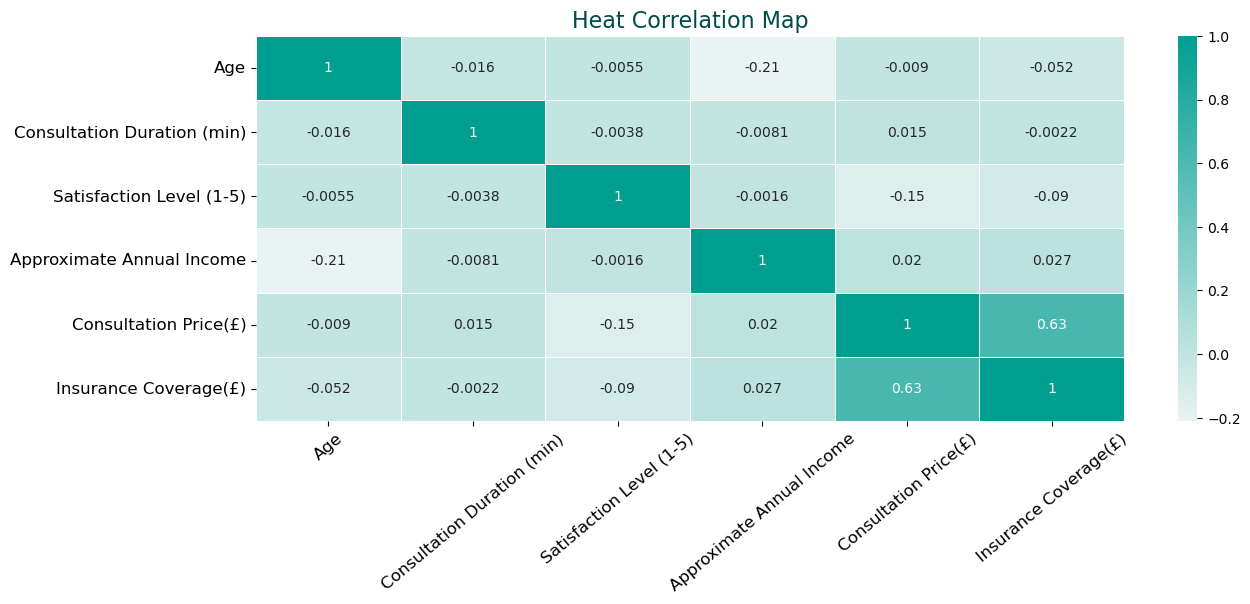

In [313]:
corr_matrix = dataset.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 5))

# Paleta verde inspirada nos teus gráficos
green_cmap = sns.light_palette("#009E91", as_cmap=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=green_cmap,
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 10})

plt.title('Heat Correlation Map', fontsize=16, color="#004C4C")
plt.xticks(rotation=40, fontsize=12)
plt.yticks(fontsize=12)
plt.show()


**15. Analysis of the Heat Correlation Map**

- **Price & Insurance (0.63)**

There is a **moderate-to-strong positive correlation (0.63)** between `Consultation Price(£)` and `Insurance Coverage(£)`. This is the most significant finding in the dataset. It indicates that higher consultation prices are strongly associated with higher insurance coverage. This suggests that patients undergoing more expensive procedures likely rely on higher insurance tiers to cover the costs, or that the clinic adjusts pricing based on coverage availability.

- **Age vs. Income Anomaly (-0.21)**

There is a **slight negative correlation (-0.21)** between `Age` and `Approximate Annual Income`. Contrary to general population trends (where income often grows with age), in this specific dataset, **older patients tend to have slightly lower incomes**. This could indicate a demographic of retirees.

- **The "Independence" of Duration**

Consultation Duration (min) has **almost zero correlation with any other variable** (values ranging from -0.016 to 0.015). This is a crucial operational insight. The length of a consultation does not dictate the price, nor does it influence customer satisfaction. **A long consultation does not guarantee a happier client, and a short one does not mean a cheaper price.**

- **Satisfaction Level**

Satisfaction Level has **very weak correlations with everything**. The strongest link (which is still weak) is negative with Consultation Price (-0.15). There is a very slight tendency for satisfaction to drop as the price increases, but it is not statistically dominant. It implies that satisfaction is likely driven by factors not present in this numeric chart (perhaps soft skills, waiting time, or outcome quality).

<div style="background-color:#009E91; padding:20px; border-radius:10px; border-left:8px"> 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #009E91;">
<h3><b>5.Conclusion and Suggestions for next analytics team</b></h3>  

### **5.1. Project Conclusion**

This project successfully transformed **raw, inconsistent** patient records into a **high-quality Analytical Base Table (ABT)**, uncovering critical operational insights for City Hospital. Through a **rigorous process of data cleaning addressing anomalies** such as 150-year-old patients, profession-age mismatches, and missing financial data—we established a reliable dataset for decision-making.

In fulfilling the role of the Data Preprocessing (DP) Team, we executed a **comprehensive workflow**:

- **Data Cleaning**: We resolved missing values, inconsistencies, and outliers to ensure a reliable foundation.

- **Feature Engineering**: We created meaningful features summarizing patient demographics, consultation behavior, and satisfaction patterns.

- **ABT Creation**: We consolidated multiple consultations into a single-row ABT, providing a holistic view suitable for clustering and predictive modeling.

**Key Strategic Insights Uncovered**:

During our exploratory analysis, **three major patterns** emerged that describe the current state of the hospital:

1. **The "Duration Paradox" (Operational Efficiency)**: We found near-zero correlation between Consultation Duration and Patient Satisfaction (or Price). This implies that longer consultations do not equate to happier patients or higher revenue. The hospital has a significant opportunity to **optimize scheduling** and **reduce average consultation times without risking patient sentiment**.

2. **Revenue Drivers:** The Emergency Department stands out as the primary revenue generator (~£323k), significantly outperforming others. The hospital's financial health is currently weighted towards acute care rather than elective specializations like ENT.

3. **The Insurance-Price Link:** A strong positive correlation (0.63) exists between Consultation Price and Insurance Coverage. Patients with better coverage consistently consume higher-priced services, suggesting that insurance tier is a **stronger predictor** of revenue than age or income.

**Final Deliverable**: By preparing high-quality data and identifying these patterns, this notebook contributes directly to City Hospital’s mission. We leave a solid foundation for the next analytics team to perform advanced clustering, segmentation, and predictive modeling.

---

### **5.2. Suggestions for the Next Analytics Team**

To build upon this foundation and move from descriptive to predictive analytics, we recommend the following roadmap:

**A. Data Engineering & Quality Automation**

- **Implement "Live" Data Validation**: Instead of cleaning errors post-hoc, implement constraints at the entry point (e.g., front-desk software preventing "Toddlers with Professions").

- **Standardize Imputation:** Codify the median imputation strategies used for Income and Age into an automated ETL pipeline to handle future data batches automatically.

- **Hospital-Centric Audits:** Implement department-specific quality checks to flag unrealistic prices or durations instantly.

- Audit **insurance coverage vs consultation price** to prevent negative or illogical financial ratios.

- Implement **department-specific quality checks** (e.g., unrealistic consultation durations or prices).



**B. Advanced Analytics & Modeling**

We recommend the following prediction targets to support resource allocation:

- **Missing Appointments Prediction**: Build a classification model to **predict missing appointments**, allowing the clinic to double-book risky slots and minimize downtime.

- **High-Utilization Forecasting:** Predict patients likely to have a high frequency of future visits.

- **Patient Satisfaction Score Prediction:** Identify service gaps and patient groups at higher dissatisfaction risk.

- Add **chronicity or intensity indicators**, such as number of visits per department, variance in consultation duration, or recurring-visit flags.

- Build **financial metrics**, including patient-level out-of-pocket cost, coverage ratio, or income-adjusted spending.



**C. Data Enrichment** 

- **Capture "Waiting Time"**: Since Consultation Duration did not explain Satisfaction, the hidden variable is likely Waiting Time. Collecting this data point is **crucial to understanding patient sentiment.**

- **Financial & Risk Metrics**: Add features such as "Patient-level out-of-pocket cost" or "Recurring-visit flags" to strengthen behavioral clustering.

- **Build Predictive Models for Key Hospital KPIs (Key Performance Indicators)**


**D. Strategic Action**

- **Price Sensitivity Clustering**: Create clusters (e.g., "High Coverage/High Value" vs. "Out-of-Pocket/Value Sensitive") to help marketing teams target **specific insurance holders with premium offers.**

- **Intervention Programs**: Work with administrators to translate these analytical findings into **satisfaction improvement plans**, specifically for underperforming departments.
- Build a **monthly refreshable ABT pipeline** so the hospital receives updated patient insights continuously.
- Develop **automated reports** summarizing demographics, high-risk patient groups, and department performance.